<a href="https://www.kaggle.com/code/lalit7881/student-cheating-networks-ai-detection-eda?scriptVersionId=348156801" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/chatgpt_detection_results.csv
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/ai_essay_submissions.csv
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/student_nodes.csv
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/assignment_design_efficacy.csv
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/plagiarism_cascades.csv
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/honor_code_violations.csv
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset/network_metrics.csv
/kaggle/input/dataset

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

In [3]:
BASE_PATH = "/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset"

print("Dataset Path:")
print(BASE_PATH)

Dataset Path:
/kaggle/input/datasets/aliahmadmphil/student-cheating-networks-and-ai-detection-data/AI_Academic_Integrity_Dataset


In [4]:
files = os.listdir(BASE_PATH)

print("Files available:")
for file in files:
    print(file)

Files available:
chatgpt_detection_results.csv
ai_essay_submissions.csv
student_nodes.csv
assignment_design_efficacy.csv
plagiarism_cascades.csv
honor_code_violations.csv
network_metrics.csv
false_positive_rates.csv
cheating_network_edges.csv
dataset_summary.txt


In [5]:
file_paths = {
    "chatgpt_detection": f"{BASE_PATH}/chatgpt_detection_results.csv",
    "ai_essay": f"{BASE_PATH}/ai_essay_submissions.csv",
    "student_nodes": f"{BASE_PATH}/student_nodes.csv",
    "assignment_design": f"{BASE_PATH}/assignment_design_efficacy.csv",
    "plagiarism_cascades": f"{BASE_PATH}/plagiarism_cascades.csv",
    "honor_code": f"{BASE_PATH}/honor_code_violations.csv",
    "network_metrics": f"{BASE_PATH}/network_metrics.csv",
    "false_positive": f"{BASE_PATH}/false_positive_rates.csv",
    "network_edges": f"{BASE_PATH}/cheating_network_edges.csv"
}

In [6]:
file_paths = {
    "chatgpt_detection": f"{BASE_PATH}/chatgpt_detection_results.csv",
    "ai_essay": f"{BASE_PATH}/ai_essay_submissions.csv",
    "student_nodes": f"{BASE_PATH}/student_nodes.csv",
    "assignment_design": f"{BASE_PATH}/assignment_design_efficacy.csv",
    "plagiarism_cascades": f"{BASE_PATH}/plagiarism_cascades.csv",
    "honor_code": f"{BASE_PATH}/honor_code_violations.csv",
    "network_metrics": f"{BASE_PATH}/network_metrics.csv",
    "false_positive": f"{BASE_PATH}/false_positive_rates.csv",
    "network_edges": f"{BASE_PATH}/cheating_network_edges.csv"
}

In [7]:
dfs = {}

for name, path in file_paths.items():
    try:
        dfs[name] = pd.read_csv(path)
        print(f"{name:25} -> {dfs[name].shape}")
    except Exception as e:
        print(f"Error loading {name}: {e}")

chatgpt_detection         -> (5000, 11)
ai_essay                  -> (3000, 10)
student_nodes             -> (200, 4)
assignment_design         -> (240, 10)
plagiarism_cascades       -> (439, 9)
honor_code                -> (5095, 7)
network_metrics           -> (1, 8)
false_positive            -> (5, 2)
network_edges             -> (135, 9)


In [8]:
for name, df in dfs.items():
    print("\n" + "=" * 70)
    print("DATASET:", name)
    print("=" * 70)
    
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    
    print("\nColumns:")
    print(df.columns.tolist())


DATASET: chatgpt_detection
Rows: 5000
Columns: 11

Columns:
['submission_id', 'tool', 'actual_type', 'detected_as_ai', 'confidence_score', 'text_length', 'subject', 'grade_level', 'writing_style_score', 'perplexity_score', 'detection_probability']

DATASET: ai_essay
Rows: 3000
Columns: 10

Columns:
['submission_id', 'semester', 'assignment_type', 'is_ai_generated', 'ai_probability', 'word_count', 'cited_references', 'similarity_score', 'submission_date', 'grade']

DATASET: student_nodes
Rows: 200
Columns: 4

Columns:
['student_id', 'year', 'major', 'gpa']

DATASET: assignment_design
Rows: 240
Columns: 10

Columns:
['design_type', 'efficacy_score', 'student_engagement', 'learning_outcome', 'ai_detection_rate', 'student_satisfaction', 'implementation_cost', 'faculty_workload', 'class_size', 'subject']

DATASET: plagiarism_cascades
Rows: 439
Columns: 9

Columns:
['cascade_id', 'student_id', 'accused_by', 'accusation_date', 'evidence_strength', 'outcome', 'cascade_level', 'subject', 'sanc

In [9]:
for name, df in dfs.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    display(df.head())


chatgpt_detection


,submission_id,tool,actual_type,detected_as_ai,confidence_score,text_length,subject,grade_level,writing_style_score,perplexity_score,detection_probability
0,SUB0000,Copyleaks,ai_generated,False,0.230527,4354,HIST,Graduate,0.371146,0.381355,0.653511
1,SUB0001,Copyleaks,human_written,False,0.643546,1056,PSYCH,Graduate,0.528367,0.248499,0.010329
2,SUB0002,Originality.ai,human_written,False,0.619367,2145,PSYCH,Freshman,0.254359,0.311960,0.009575
3,SUB0003,Copyleaks,human_written,False,0.570965,1579,MATH,Freshman,0.575367,0.263869,0.018074
4,SUB0004,GPTZero,human_written,False,0.335957,3153,BIO,Graduate,0.310787,0.350734,0.121960



ai_essay


,submission_id,semester,assignment_type,is_ai_generated,ai_probability,word_count,cited_references,similarity_score,submission_date,grade
0,AI0000,Fall 2026,Case Study,False,0.497984,1438.378109,10,34.754395,2026-08-08 21:49:52.565672,58.295396
1,AI0001,Fall 2026,Essay,False,0.542958,1311.805129,8,42.488394,2026-08-06 21:49:52.572432,96.911519
2,AI0002,Fall 2026,Research Paper,True,0.564619,1406.876124,4,35.136599,2026-07-20 21:49:52.573326,72.333481
3,AI0003,Summer 2026,Lab Report,False,0.367349,1764.196251,8,12.057463,2026-08-27 21:49:52.574060,98.127509
4,AI0004,Fall 2026,Essay,False,0.693773,699.388496,6,34.186311,2026-03-26 21:49:52.574758,74.285079



student_nodes


...

,num_nodes,num_edges,density,avg_clustering,num_strongly_connected,max_in_degree,max_out_degree,avg_shortest_path
0,200,135,0.003392,0.121048,161,9,9,NaN



false_positive


,tool,detected_as_ai
0,Copyleaks,0.026694
1,GPTZero,0.150862
2,Originality.ai,0.003906
3,Turnitin,0.059794
4,Winston AI,0.105566



network_edges


,source,target,edge_type,confidence,timestamp,source_year,target_year,source_major,target_major
0,S001,S140,code_copying,0.799460,2026-06-21 21:49:50.113079,2,4,BIO,MATH
1,S001,S139,exam_sharing,0.281209,2026-09-01 21:49:50.113194,2,4,BIO,PHYS
2,S001,S102,answer_distribution,0.414888,2026-07-18 21:49:50.113308,2,3,BIO,PHYS
3,S001,S096,exam_sharing,0.263272,2026-07-07 21:49:50.113423,2,3,BIO,ENG
4,S001,S092,essay_sharing,0.269575,2026-07-04 21:49:50.132531,2,3,BIO,BIO


In [10]:
for name, df in dfs.items():
    print("\n", name)
    display(df.tail())


 chatgpt_detection


,submission_id,tool,actual_type,detected_as_ai,confidence_score,text_length,subject,grade_level,writing_style_score,perplexity_score,detection_probability
4995,SUB4995,Copyleaks,human_written,False,0.201962,4367,PHYS,Senior,0.403646,0.234323,0.0000
4996,SUB4996,Originality.ai,human_written,False,0.252796,4355,PSYCH,Sophomore,0.590153,0.364090,0.0000
4997,SUB4997,GPTZero,ai_generated,True,0.155083,794,PSYCH,Junior,0.452023,0.472642,1.0000
4998,SUB4998,Copyleaks,human_written,False,0.358311,907,PHYS,Graduate,0.368542,0.282774,0.0000
4999,SUB4999,Copyleaks,ai_generated,True,0.256808,3412,PHYS,Graduate,0.285944,0.196872,0.8528



 ai_essay


,submission_id,semester,assignment_type,is_ai_generated,ai_probability,word_count,cited_references,similarity_score,submission_date,grade
2995,AI2995,Fall 2026,Essay,True,0.523462,1272.185327,7,35.952413,2026-05-12 21:49:54.100903,77.282279
2996,AI2996,Fall 2026,Lab Report,False,0.434876,1170.007830,11,56.464734,2026-08-22 21:49:54.101161,63.124971
2997,AI2997,Summer 2026,Literature Review,False,0.547898,1010.264029,10,19.700139,2026-08-21 21:49:54.101405,49.240741
2998,AI2998,Fall 2026,Lab Report,False,0.415637,1544.096339,4,41.970858,2026-08-21 21:49:54.101646,64.527819
2999,AI2999,Fall 2026,Research Paper,False,0.526404,1817.772317,6,14.262286,2026-07-30 21:49:54.101886,64.427797



 student_nodes


...

,num_nodes,num_edges,density,avg_clustering,num_strongly_connected,max_in_degree,max_out_degree,avg_shortest_path
0,200,135,0.003392,0.121048,161,9,9,NaN



 false_positive


,tool,detected_as_ai
0,Copyleaks,0.026694
1,GPTZero,0.150862
2,Originality.ai,0.003906
3,Turnitin,0.059794
4,Winston AI,0.105566



 network_edges


,source,target,edge_type,confidence,timestamp,source_year,target_year,source_major,target_major
130,S191,S170,essay_sharing,0.713186,2026-08-02 21:49:50.122224,1,1,ENG,ENG
131,S194,S172,essay_sharing,0.453615,2026-08-23 21:49:50.141579,3,1,CHEM,MATH
132,S199,S122,essay_sharing,0.225002,2026-07-01 21:49:50.130480,2,3,CS,ENG
133,S199,S106,code_copying,0.632314,2026-06-10 21:49:50.130597,2,1,CS,PHYS
134,S199,S041,answer_distribution,0.845495,2026-08-25 21:49:50.130712,2,1,CS,CS


In [11]:
for name, df in dfs.items():
    print("\n", name)
    display(df.sample(min(5, len(df)), random_state=42))


 chatgpt_detection


,submission_id,tool,actual_type,detected_as_ai,confidence_score,text_length,subject,grade_level,writing_style_score,perplexity_score,detection_probability
1501,SUB1501,Copyleaks,human_written,False,0.234880,4165,PHYS,Senior,0.643306,0.268026,0.000000
2586,SUB2586,Turnitin,human_written,True,0.232391,956,PSYCH,Graduate,0.362552,0.239009,0.078548
2653,SUB2653,Originality.ai,human_written,False,0.301485,2913,BIO,Junior,0.726028,0.328919,0.000000
1055,SUB1055,Winston AI,mixed,False,0.152684,3128,ENG,Senior,0.518811,0.196220,0.701512
705,SUB0705,Turnitin,human_written,False,0.596257,2518,PHYS,Junior,0.563779,0.509569,0.036249



 ai_essay


,submission_id,semester,assignment_type,is_ai_generated,ai_probability,word_count,cited_references,similarity_score,submission_date,grade
1801,AI1801,Summer 2026,Research Paper,False,0.417691,901.166683,12,13.852465,2026-07-28 21:49:53.664746,57.527929
1190,AI1190,Fall 2026,Research Paper,False,0.467402,1137.308075,10,22.636623,2026-03-27 21:49:53.246727,69.706437
1817,AI1817,Fall 2026,Research Paper,False,0.595989,1547.586118,14,23.302731,2026-04-11 21:49:53.670854,60.498220
251,AI0251,Fall 2026,Lab Report,True,0.403740,1412.454893,6,13.660048,2026-07-13 21:49:52.722588,75.403233
2505,AI2505,Spring 2026,Research Paper,True,0.316778,1274.134907,5,32.012927,2026-07-06 21:49:53.915160,71.827322



 student_nodes


...

,num_nodes,num_edges,density,avg_clustering,num_strongly_connected,max_in_degree,max_out_degree,avg_shortest_path
0,200,135,0.003392,0.121048,161,9,9,NaN



 false_positive


,tool,detected_as_ai
1,GPTZero,0.150862
4,Winston AI,0.105566
2,Originality.ai,0.003906
0,Copyleaks,0.026694
3,Turnitin,0.059794



 network_edges


,source,target,edge_type,confidence,timestamp,source_year,target_year,source_major,target_major
98,S138,S157,exam_sharing,0.627018,2026-07-15 21:49:50.109245,1,3,MATH,CS
67,S096,S140,exam_sharing,0.374744,2026-07-15 21:49:50.111646,3,4,ENG,MATH
105,S141,S018,exam_sharing,0.525767,2026-06-16 21:49:50.118072,3,3,CS,PHYS
19,S013,S157,answer_distribution,0.384106,2026-08-16 21:49:50.110115,1,3,ENG,CS
42,S048,S175,code_copying,0.945473,2026-07-04 21:49:50.137326,2,3,MATH,MATH


In [12]:
summary = []

for name, df in dfs.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing_Values": df.isnull().sum().sum(),
        "Duplicate_Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Dataset,Rows,Columns,Missing_Values,Duplicate_Rows
0,chatgpt_detection,5000,11,0,0
1,ai_essay,3000,10,0,0
2,student_nodes,200,4,0,0
3,assignment_design,240,10,0,0
4,plagiarism_cascades,439,9,80,0
5,honor_code,5095,7,0,3
6,network_metrics,1,8,1,0
7,false_positive,5,2,0,0
8,network_edges,135,9,0,0


In [13]:
summary_df.sort_values(
    by="Rows",
    ascending=False
)

,Dataset,Rows,Columns,Missing_Values,Duplicate_Rows
5,honor_code,5095,7,0,3
0,chatgpt_detection,5000,11,0,0
1,ai_essay,3000,10,0,0
4,plagiarism_cascades,439,9,80,0
3,assignment_design,240,10,0,0
2,student_nodes,200,4,0,0
8,network_edges,135,9,0,0
7,false_positive,5,2,0,0
6,network_metrics,1,8,1,0


In [14]:
for name, df in dfs.items():
    
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    display(
        pd.DataFrame({
            "Column": df.columns,
            "Data_Type": df.dtypes.astype(str).values,
            "Non_Null_Count": df.notnull().sum().values,
            "Missing_Count": df.isnull().sum().values,
            "Unique_Count": df.nunique().values
        })
    )


chatgpt_detection


,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Count
0,submission_id,object,5000,0,5000
1,tool,object,5000,0,5
2,actual_type,object,5000,0,3
3,detected_as_ai,bool,5000,0,2
4,confidence_score,float64,5000,0,5000
5,text_length,int64,5000,0,3018
6,subject,object,5000,0,8
7,grade_level,object,5000,0,5
8,writing_style_score,float64,5000,0,5000
9,perplexity_score,float64,5000,0,5000



ai_essay


,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Count
0,submission_id,object,3000,0,3000
1,semester,object,3000,0,4
2,assignment_type,object,3000,0,5
3,is_ai_generated,bool,3000,0,2
4,ai_probability,float64,3000,0,2999
5,word_count,float64,3000,0,3000
6,cited_references,int64,3000,0,20
7,similarity_score,float64,3000,0,3000
8,submission_date,object,3000,0,3000
9,grade,float64,3000,0,2961



student_nodes


...

,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Count
0,num_nodes,int64,1,0,1
1,num_edges,int64,1,0,1
2,density,float64,1,0,1
3,avg_clustering,float64,1,0,1
4,num_strongly_connected,int64,1,0,1
5,max_in_degree,int64,1,0,1
6,max_out_degree,int64,1,0,1
7,avg_shortest_path,float64,0,1,0



false_positive


,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Count
0,tool,object,5,0,5
1,detected_as_ai,float64,5,0,5



network_edges


,Column,Data_Type,Non_Null_Count,Missing_Count,Unique_Count
0,source,object,135,0,63
1,target,object,135,0,59
2,edge_type,object,135,0,4
3,confidence,float64,135,0,135
4,timestamp,object,135,0,135
5,source_year,int64,135,0,4
6,target_year,int64,135,0,4
7,source_major,object,135,0,6
8,target_major,object,135,0,6


In [15]:
for name, df in dfs.items():
    
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    df.info()


chatgpt_detection
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_id          5000 non-null   object 
 1   tool                   5000 non-null   object 
 2   actual_type            5000 non-null   object 
 3   detected_as_ai         5000 non-null   bool   
 4   confidence_score       5000 non-null   float64
 5   text_length            5000 non-null   int64  
 6   subject                5000 non-null   object 
 7   grade_level            5000 non-null   object 
 8   writing_style_score    5000 non-null   float64
 9   perplexity_score       5000 non-null   float64
 10  detection_probability  5000 non-null   float64
dtypes: bool(1), float64(4), int64(1), object(5)
memory usage: 395.6+ KB

ai_essay
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Col

In [16]:
missing_summary = {}

for name, df in dfs.items():
    
    temp = pd.DataFrame({
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (
            df.isnull().sum() / len(df) * 100
        ).round(2)
    })
    
    temp = temp[temp["Missing_Count"] > 0]
    
    missing_summary[name] = temp
    
    print("\n", name)
    display(temp)


 chatgpt_detection


,Missing_Count,Missing_Percentage



 ai_essay


,Missing_Count,Missing_Percentage



 student_nodes


...

,Missing_Count,Missing_Percentage
avg_shortest_path,1,100.0



 false_positive


,Missing_Count,Missing_Percentage



 network_edges


,Missing_Count,Missing_Percentage


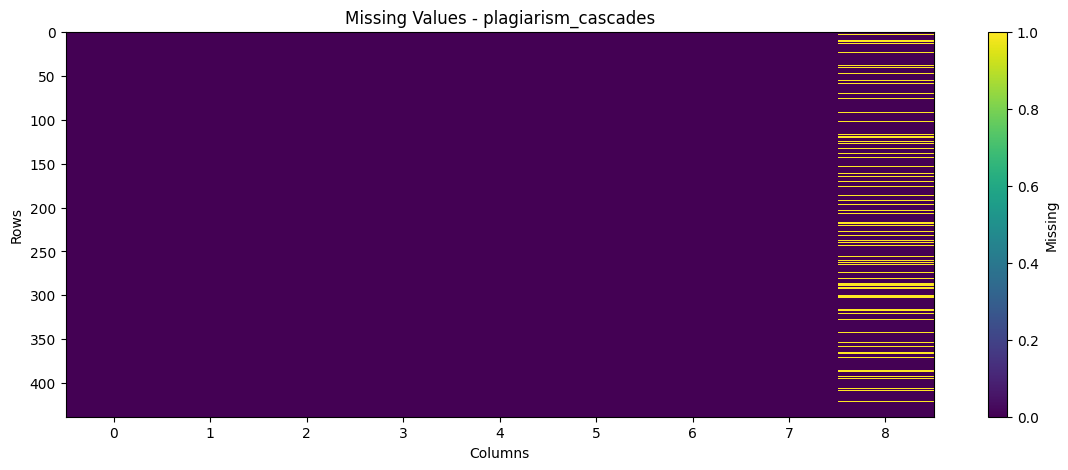

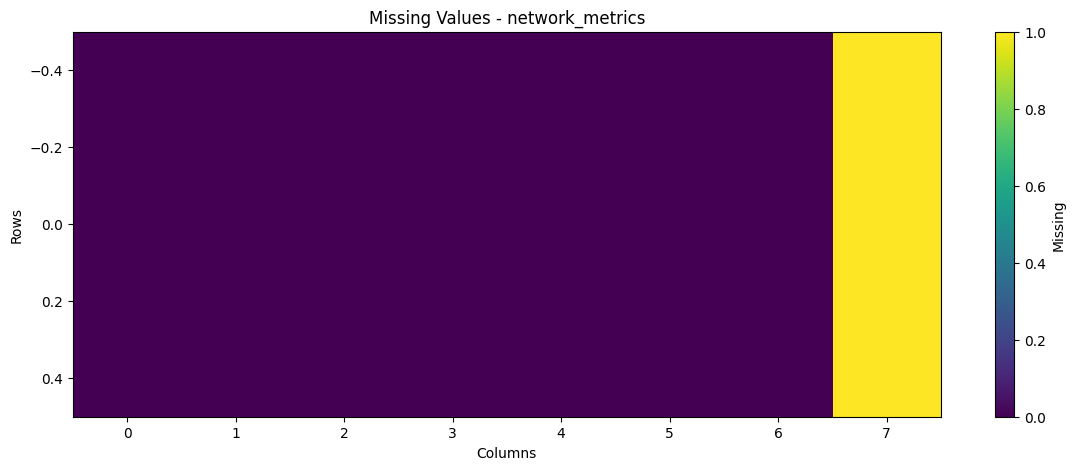

In [17]:
import matplotlib.pyplot as plt

for name, df in dfs.items():
    
    if df.isnull().sum().sum() > 0:
        
        plt.figure(figsize=(14, 5))
        
        plt.imshow(
            df.isnull(),
            aspect="auto",
            interpolation="nearest"
        )
        
        plt.title(f"Missing Values - {name}")
        plt.xlabel("Columns")
        plt.ylabel("Rows")
        plt.colorbar(label="Missing")
        
        plt.show()

In [18]:
for name, df in dfs.items():
    
    duplicate_count = df.duplicated().sum()
    
    print(
        f"{name:25} -> "
        f"{duplicate_count} duplicate rows"
    )

chatgpt_detection         -> 0 duplicate rows
ai_essay                  -> 0 duplicate rows
student_nodes             -> 0 duplicate rows
assignment_design         -> 0 duplicate rows
plagiarism_cascades       -> 0 duplicate rows
honor_code                -> 3 duplicate rows
network_metrics           -> 0 duplicate rows
false_positive            -> 0 duplicate rows
network_edges             -> 0 duplicate rows


In [19]:
for name, df in dfs.items():
    
    duplicates = df[df.duplicated(keep=False)]
    
    if len(duplicates) > 0:
        print("\n", name)
        display(duplicates.head(20))


 honor_code


,date,violation_type,severity,course,reported_by,investigation_duration,appealed
3921,2026-07-08,Plagiarism,Minor,PHYS101,Peer,15,False
3926,2026-07-08,Plagiarism,Minor,PHYS101,Peer,15,False
4591,2026-10-13,Unauthorized AI Use,Major,PHYS101,Administrator,16,False
4593,2026-10-13,Unauthorized AI Use,Major,PHYS101,Administrator,16,False
4674,2026-10-24,Fabrication,Moderate,CS101,Peer,16,False
4679,2026-10-24,Fabrication,Moderate,CS101,Peer,16,False


In [20]:
clean_dfs = {}

for name, df in dfs.items():
    
    clean_dfs[name] = df.drop_duplicates().copy()
    
    print(
        name,
        "Before:", len(df),
        "After:", len(clean_dfs[name])
    )

chatgpt_detection Before: 5000 After: 5000
ai_essay Before: 3000 After: 3000
student_nodes Before: 200 After: 200
assignment_design Before: 240 After: 240
plagiarism_cascades Before: 439 After: 439
honor_code Before: 5095 After: 5092
network_metrics Before: 1 After: 1
false_positive Before: 5 After: 5
network_edges Before: 135 After: 135


In [21]:
for name, df in dfs.items():
    
    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns.tolist()
    
    print("\n", name)
    print("Numerical columns:")
    print(numeric_columns)


 chatgpt_detection
Numerical columns:
['confidence_score', 'text_length', 'writing_style_score', 'perplexity_score', 'detection_probability']

 ai_essay
Numerical columns:
['ai_probability', 'word_count', 'cited_references', 'similarity_score', 'grade']

 student_nodes
Numerical columns:
['year', 'gpa']

 assignment_design
Numerical columns:
['efficacy_score', 'student_engagement', 'learning_outcome', 'ai_detection_rate', 'student_satisfaction', 'class_size']

 plagiarism_cascades
Numerical columns:
['evidence_strength', 'cascade_level']

 honor_code
Numerical columns:
['investigation_duration']

 network_metrics
Numerical columns:
['num_nodes', 'num_edges', 'density', 'avg_clustering', 'num_strongly_connected', 'max_in_degree', 'max_out_degree', 'avg_shortest_path']

 false_positive
Numerical columns:
['detected_as_ai']

 network_edges
Numerical columns:
['confidence', 'source_year', 'target_year']


In [22]:
for name, df in dfs.items():
    
    categorical_columns = df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
    
    print("\n", name)
    print("Categorical columns:")
    print(categorical_columns)


 chatgpt_detection
Categorical columns:
['submission_id', 'tool', 'actual_type', 'subject', 'grade_level']

 ai_essay
Categorical columns:
['submission_id', 'semester', 'assignment_type', 'submission_date']

 student_nodes
Categorical columns:
['student_id', 'major']

 assignment_design
Categorical columns:
['design_type', 'implementation_cost', 'faculty_workload', 'subject']

 plagiarism_cascades
Categorical columns:
['cascade_id', 'student_id', 'accused_by', 'accusation_date', 'outcome', 'subject', 'sanction_level']

 honor_code
Categorical columns:
['date', 'violation_type', 'severity', 'course', 'reported_by']

 network_metrics
Categorical columns:
[]

 false_positive
Categorical columns:
['tool']

 network_edges
Categorical columns:
['source', 'target', 'edge_type', 'timestamp', 'source_major', 'target_major']


In [23]:
for name, df in dfs.items():
    
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    display(
        df.describe(include="number").T
    )


chatgpt_detection


,count,mean,std,min,25%,50%,75%,max
confidence_score,5000.0,0.404434,0.200006,0.011300,0.244397,0.390976,0.550331,0.972789
text_length,5000.0,2773.430400,1316.035996,500.000000,1610.750000,2768.500000,3940.000000,4999.000000
writing_style_score,5000.0,0.501041,0.150685,-0.051191,0.400205,0.500953,0.602027,1.027051
perplexity_score,5000.0,0.299272,0.101908,-0.053886,0.229444,0.300340,0.369089,0.690280
detection_probability,5000.0,0.379692,0.354421,0.000000,0.056165,0.192592,0.753424,1.000000



ai_essay


,count,mean,std,min,25%,50%,75%,max
ai_probability,3000.0,0.421607,0.150656,0.000000,0.316757,0.425426,0.535478,0.855017
word_count,3000.0,1496.521470,395.855132,110.824597,1229.521591,1492.912170,1760.749055,2936.799659
cited_references,3000.0,7.980333,2.833012,0.000000,6.000000,8.000000,10.000000,19.000000
similarity_score,3000.0,33.077896,17.780712,0.298162,19.105090,31.252404,45.297626,93.159729
grade,3000.0,76.153191,9.631989,31.709142,71.032950,76.743921,81.936854,100.000000



student_nodes


...

,count,mean,std,min,25%,50%,75%,max
num_nodes,1.0,200.000000,NaN,200.000000,200.000000,200.000000,200.000000,200.000000
num_edges,1.0,135.000000,NaN,135.000000,135.000000,135.000000,135.000000,135.000000
density,1.0,0.003392,NaN,0.003392,0.003392,0.003392,0.003392,0.003392
avg_clustering,1.0,0.121048,NaN,0.121048,0.121048,0.121048,0.121048,0.121048
num_strongly_connected,1.0,161.000000,NaN,161.000000,161.000000,161.000000,161.000000,161.000000
max_in_degree,1.0,9.000000,NaN,9.000000,9.000000,9.000000,9.000000,9.000000
max_out_degree,1.0,9.000000,NaN,9.000000,9.000000,9.000000,9.000000,9.000000
avg_shortest_path,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



false_positive


,count,mean,std,min,25%,50%,75%,max
detected_as_ai,5.0,0.069364,0.059476,0.003906,0.026694,0.059794,0.105566,0.150862



network_edges


,count,mean,std,min,25%,50%,75%,max
confidence,135.0,0.508849,0.224576,0.061313,0.342561,0.514162,0.695679,0.988982
source_year,135.0,2.229630,1.132562,1.000000,1.000000,2.000000,3.000000,4.000000
target_year,135.0,2.370370,1.111277,1.000000,1.000000,2.000000,3.000000,4.000000


In [24]:
for name, df in dfs.items():
    
    print("\n", name)
    
    display(
        df.describe(include="all").T
    )


 chatgpt_detection


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
submission_id,5000,5000,SUB4999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tool,5000,5,Originality.ai,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actual_type,5000,3,human_written,2469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detected_as_ai,5000,2,False,3101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
confidence_score,5000.0,NaN,NaN,NaN,0.404434,0.200006,0.0113,0.244397,0.390976,0.550331,0.972789
text_length,5000.0,NaN,NaN,NaN,2773.4304,1316.035996,500.0,1610.75,2768.5,3940.0,4999.0
subject,5000,8,CS,649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grade_level,5000,5,Graduate,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
writing_style_score,5000.0,NaN,NaN,NaN,0.501041,0.150685,-0.051191,0.400205,0.500953,0.602027,1.027051
perplexity_score,5000.0,NaN,NaN,NaN,0.299272,0.101908,-0.053886,0.229444,0.30034,0.369089,0.69028



 ai_essay


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
submission_id,3000,3000,AI2999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
semester,3000,4,Fall 2026,1185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
assignment_type,3000,5,Research Paper,609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_ai_generated,3000,2,False,1792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_probability,3000.0,NaN,NaN,NaN,0.421607,0.150656,0.0,0.316757,0.425426,0.535478,0.855017
word_count,3000.0,NaN,NaN,NaN,1496.52147,395.855132,110.824597,1229.521591,1492.91217,1760.749055,2936.799659
cited_references,3000.0,NaN,NaN,NaN,7.980333,2.833012,0.0,6.0,8.0,10.0,19.0
similarity_score,3000.0,NaN,NaN,NaN,33.077896,17.780712,0.298162,19.10509,31.252404,45.297626,93.159729
submission_date,3000,3000,2026-07-30 21:49:54.101886,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grade,3000.0,NaN,NaN,NaN,76.153191,9.631989,31.709142,71.03295,76.743921,81.936854,100.0



 student_nodes


...

,count,mean,std,min,25%,50%,75%,max
num_nodes,1.0,200.000000,NaN,200.000000,200.000000,200.000000,200.000000,200.000000
num_edges,1.0,135.000000,NaN,135.000000,135.000000,135.000000,135.000000,135.000000
density,1.0,0.003392,NaN,0.003392,0.003392,0.003392,0.003392,0.003392
avg_clustering,1.0,0.121048,NaN,0.121048,0.121048,0.121048,0.121048,0.121048
num_strongly_connected,1.0,161.000000,NaN,161.000000,161.000000,161.000000,161.000000,161.000000
max_in_degree,1.0,9.000000,NaN,9.000000,9.000000,9.000000,9.000000,9.000000
max_out_degree,1.0,9.000000,NaN,9.000000,9.000000,9.000000,9.000000,9.000000
avg_shortest_path,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



 false_positive


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tool,5,5,Copyleaks,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detected_as_ai,5.0,NaN,NaN,NaN,0.069364,0.059476,0.003906,0.026694,0.059794,0.105566,0.150862



 network_edges


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source,135,63,S102,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,135,59,S102,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edge_type,135,4,answer_distribution,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
confidence,135.0,NaN,NaN,NaN,0.508849,0.224576,0.061313,0.342561,0.514162,0.695679,0.988982
timestamp,135,135,2026-06-21 21:49:50.113079,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_year,135.0,NaN,NaN,NaN,2.22963,1.132562,1.0,1.0,2.0,3.0,4.0
target_year,135.0,NaN,NaN,NaN,2.37037,1.111277,1.0,1.0,2.0,3.0,4.0
source_major,135,6,BIO,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_major,135,6,BIO,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
for name, df in dfs.items():
    
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    for col in df.columns:
        
        print(
            f"\nColumn: {col}"
        )
        
        print(
            "Unique values:",
            df[col].nunique()
        )
        
        if df[col].nunique() <= 20:
            print(
                df[col].unique()
            )


chatgpt_detection

Column: submission_id
Unique values: 5000

Column: tool
Unique values: 5
['Copyleaks' 'Originality.ai' 'GPTZero' 'Winston AI' 'Turnitin']

Column: actual_type
Unique values: 3
['ai_generated' 'human_written' 'mixed']

Column: detected_as_ai
Unique values: 2
[False  True]

Column: confidence_score
Unique values: 5000

Column: text_length
Unique values: 3018

Column: subject
Unique values: 8
['HIST' 'PSYCH' 'MATH' 'BIO' 'PHYS' 'CS' 'CHEM' 'ENG']

Column: grade_level
Unique values: 5
['Graduate' 'Freshman' 'Senior' 'Junior' 'Sophomore']

Column: writing_style_score
Unique values: 5000

Column: perplexity_score
Unique values: 5000

Column: detection_probability
Unique values: 4409

ai_essay

Column: submission_id
Unique values: 3000

Column: semester
Unique values: 4
['Fall 2026' 'Summer 2026' 'Spring 2026' 'Fall 2025']

Column: assignment_type
Unique values: 5
['Case Study' 'Essay' 'Research Paper' 'Lab Report' 'Literature Review']

Column: is_ai_generated
Unique value

In [26]:
for name, df in dfs.items():
    
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    
    categorical_cols = df.select_dtypes(
        include=["object", "category"]
    ).columns
    
    for col in categorical_cols:
        
        print(f"\n{col}")
        
        display(
            df[col]
            .value_counts(dropna=False)
            .head(20)
        )


chatgpt_detection

submission_id


submission_id
SUB4999    1
SUB0000    1
SUB0001    1
SUB0002    1
SUB0003    1
SUB0004    1
SUB0005    1
SUB0006    1
SUB4983    1
SUB4982    1
SUB4981    1
SUB4980    1
SUB4979    1
SUB4978    1
SUB4977    1
SUB4976    1
SUB4975    1
SUB4974    1
SUB4973    1
SUB4972    1
Name: count, dtype: int64


tool


tool
Originality.ai    1015
Copyleaks         1005
Winston AI        1001
Turnitin           997
GPTZero            982
Name: count, dtype: int64


actual_type


...

timestamp
2026-06-21 21:49:50.113079    1
2026-09-01 21:49:50.113194    1
2026-07-18 21:49:50.113308    1
2026-07-07 21:49:50.113423    1
2026-07-04 21:49:50.132531    1
2026-08-14 21:49:50.132646    1
2026-08-30 21:49:50.114374    1
2026-07-12 21:49:50.114489    1
2026-07-11 21:49:50.114609    1
2026-07-19 21:49:50.118720    1
2026-08-20 21:49:50.118837    1
2026-08-21 21:49:50.135709    1
2026-07-29 21:49:50.120412    1
2026-07-18 21:49:50.117215    1
2026-08-11 21:49:50.117387    1
2026-06-13 21:49:50.117526    1
2026-06-10 21:49:50.117666    1
2026-08-22 21:49:50.134828    1
2026-06-25 21:49:50.109998    1
2026-08-16 21:49:50.110115    1
Name: count, dtype: int64


source_major


source_major
BIO     29
PHYS    26
ENG     23
CS      21
MATH    20
CHEM    16
Name: count, dtype: int64


target_major


target_major
BIO     35
PHYS    27
CS      20
ENG     20
MATH    18
CHEM    15
Name: count, dtype: int64

In [27]:
for name, df in dfs.items():
    
    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    for col in numeric_cols:
        
        print(
            f"{name} -> {col}"
        )
        
        display(
            df[col].describe()
        )

chatgpt_detection -> confidence_score


count    5000.000000
mean        0.404434
std         0.200006
min         0.011300
25%         0.244397
50%         0.390976
75%         0.550331
max         0.972789
Name: confidence_score, dtype: float64

chatgpt_detection -> text_length


count    5000.000000
mean     2773.430400
std      1316.035996
min       500.000000
25%      1610.750000
50%      2768.500000
75%      3940.000000
max      4999.000000
Name: text_length, dtype: float64

chatgpt_detection -> writing_style_score


...

count    135.000000
mean       0.508849
std        0.224576
min        0.061313
25%        0.342561
50%        0.514162
75%        0.695679
max        0.988982
Name: confidence, dtype: float64

network_edges -> source_year


count    135.000000
mean       2.229630
std        1.132562
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: source_year, dtype: float64

network_edges -> target_year


count    135.000000
mean       2.370370
std        1.111277
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: target_year, dtype: float64

In [28]:
for name, df in dfs.items():
    
    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    if len(numeric_cols) > 0:
        
        statistics = pd.DataFrame({
            "Mean": df[numeric_cols].mean(),
            "Median": df[numeric_cols].median(),
            "Minimum": df[numeric_cols].min(),
            "Maximum": df[numeric_cols].max(),
            "Std_Dev": df[numeric_cols].std()
        })
        
        print("\n", name)
        display(statistics)


 chatgpt_detection


,Mean,Median,Minimum,Maximum,Std_Dev
confidence_score,0.404434,0.390976,0.011300,0.972789,0.200006
text_length,2773.430400,2768.500000,500.000000,4999.000000,1316.035996
writing_style_score,0.501041,0.500953,-0.051191,1.027051,0.150685
perplexity_score,0.299272,0.300340,-0.053886,0.690280,0.101908
detection_probability,0.379692,0.192592,0.000000,1.000000,0.354421



 ai_essay


,Mean,Median,Minimum,Maximum,Std_Dev
ai_probability,0.421607,0.425426,0.000000,0.855017,0.150656
word_count,1496.521470,1492.912170,110.824597,2936.799659,395.855132
cited_references,7.980333,8.000000,0.000000,19.000000,2.833012
similarity_score,33.077896,31.252404,0.298162,93.159729,17.780712
grade,76.153191,76.743921,31.709142,100.000000,9.631989



 student_nodes


...

,Mean,Median,Minimum,Maximum,Std_Dev
num_nodes,200.000000,200.000000,200.000000,200.000000,NaN
num_edges,135.000000,135.000000,135.000000,135.000000,NaN
density,0.003392,0.003392,0.003392,0.003392,NaN
avg_clustering,0.121048,0.121048,0.121048,0.121048,NaN
num_strongly_connected,161.000000,161.000000,161.000000,161.000000,NaN
max_in_degree,9.000000,9.000000,9.000000,9.000000,NaN
max_out_degree,9.000000,9.000000,9.000000,9.000000,NaN
avg_shortest_path,NaN,NaN,NaN,NaN,NaN



 false_positive


,Mean,Median,Minimum,Maximum,Std_Dev
detected_as_ai,0.069364,0.059794,0.003906,0.150862,0.059476



 network_edges


,Mean,Median,Minimum,Maximum,Std_Dev
confidence,0.508849,0.514162,0.061313,0.988982,0.224576
source_year,2.229630,2.000000,1.000000,4.000000,1.132562
target_year,2.370370,2.000000,1.000000,4.000000,1.111277


In [29]:
for name, df in dfs.items():
    
    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    if len(numeric_cols) > 0:
        
        col = numeric_cols[0]
        
        filtered = df[
            df[col] > df[col].median()
        ]
        
        print(
            f"{name}: {len(filtered)} rows above median"
        )

chatgpt_detection: 2500 rows above median
ai_essay: 1500 rows above median
student_nodes: 87 rows above median
assignment_design: 120 rows above median
plagiarism_cascades: 219 rows above median
honor_code: 2193 rows above median
network_metrics: 0 rows above median
false_positive: 2 rows above median
network_edges: 67 rows above median


In [30]:
for name, df in dfs.items():
    
    cat_cols = df.select_dtypes(
        include=["object", "category"]
    ).columns
    
    num_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    if len(cat_cols) > 0 and len(num_cols) > 0:
        
        cat = cat_cols[0]
        num = num_cols[0]
        
        print(
            f"\n{name}: {cat} vs {num}"
        )
        
        result = (
            df.groupby(cat)[num]
            .agg(["count", "mean", "median", "min", "max"])
            .sort_values("mean", ascending=False)
        )
        
        display(result.head(20))


chatgpt_detection: submission_id vs confidence_score


,count,mean,median,min,max
submission_id,,,,,
SUB4132,1,0.972789,0.972789,0.972789,0.972789
SUB1090,1,0.946852,0.946852,0.946852,0.946852
SUB2468,1,0.945629,0.945629,0.945629,0.945629
SUB1735,1,0.935816,0.935816,0.935816,0.935816
SUB0731,1,0.932654,0.932654,0.932654,0.932654
SUB1112,1,0.932088,0.932088,0.932088,0.932088
SUB1518,1,0.925869,0.925869,0.925869,0.925869
SUB3526,1,0.924545,0.924545,0.924545,0.924545
SUB2138,1,0.922902,0.922902,0.922902,0.922902



ai_essay: submission_id vs ai_probability


,count,mean,median,min,max
submission_id,,,,,
AI1100,1,0.855017,0.855017,0.855017,0.855017
AI0544,1,0.766072,0.766072,0.766072,0.766072
AI0727,1,0.759200,0.759200,0.759200,0.759200
AI0528,1,0.757047,0.757047,0.757047,0.757047
AI2019,1,0.753454,0.753454,0.753454,0.753454
AI0452,1,0.753080,0.753080,0.753080,0.753080
AI1226,1,0.749048,0.749048,0.749048,0.749048
AI2876,1,0.740443,0.740443,0.740443,0.740443
AI1904,1,0.740063,0.740063,0.740063,0.740063



student_nodes: student_id vs year


...

,count,mean,median,min,max
date,,,,,
2026-09-20,2,22.000000,22.0,20,24
2025-03-24,3,21.666667,21.0,19,25
2025-05-06,2,20.000000,20.0,16,24
2025-02-09,4,19.750000,20.0,15,24
2026-08-22,3,19.666667,21.0,16,22
2026-02-12,5,19.600000,20.0,16,24
2025-01-11,4,19.000000,18.5,13,26
2025-06-02,3,19.000000,20.0,14,23
2026-05-28,6,19.000000,17.5,17,24



false_positive: tool vs detected_as_ai


,count,mean,median,min,max
tool,,,,,
GPTZero,1,0.150862,0.150862,0.150862,0.150862
Winston AI,1,0.105566,0.105566,0.105566,0.105566
Turnitin,1,0.059794,0.059794,0.059794,0.059794
Copyleaks,1,0.026694,0.026694,0.026694,0.026694
Originality.ai,1,0.003906,0.003906,0.003906,0.003906



network_edges: source vs confidence


,count,mean,median,min,max
source,,,,,
S038,1,0.988982,0.988982,0.988982,0.988982
S048,3,0.890057,0.869663,0.855034,0.945473
S088,1,0.815263,0.815263,0.815263,0.815263
S082,1,0.789109,0.789109,0.789109,0.789109
S072,1,0.788448,0.788448,0.788448,0.788448
S150,1,0.774844,0.774844,0.774844,0.774844
S094,1,0.740339,0.740339,0.740339,0.740339
S191,1,0.713186,0.713186,0.713186,0.713186
S138,3,0.709310,0.730219,0.627018,0.770692


In [31]:
for name, df in dfs.items():
    
    cat_cols = df.select_dtypes(
        include=["object", "category"]
    ).columns
    
    num_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    if len(cat_cols) >= 1 and len(num_cols) >= 1:
        
        cat = cat_cols[0]
        num = num_cols[0]
        
        result = df.groupby(cat).agg(
            Count=(num, "count"),
            Mean=(num, "mean"),
            Median=(num, "median"),
            Std=(num, "std"),
            Minimum=(num, "min"),
            Maximum=(num, "max")
        )
        
        display(result)

,Count,Mean,Median,Std,Minimum,Maximum
submission_id,,,,,,
SUB0000,1,0.230527,0.230527,NaN,0.230527,0.230527
SUB0001,1,0.643546,0.643546,NaN,0.643546,0.643546
SUB0002,1,0.619367,0.619367,NaN,0.619367,0.619367
SUB0003,1,0.570965,0.570965,NaN,0.570965,0.570965
SUB0004,1,0.335957,0.335957,NaN,0.335957,0.335957
...,...,...,...,...,...,...
SUB4995,1,0.201962,0.201962,NaN,0.201962,0.201962
SUB4996,1,0.252796,0.252796,NaN,0.252796,0.252796
SUB4997,1,0.155083,0.155083,NaN,0.155083,0.155083


,Count,Mean,Median,Std,Minimum,Maximum
submission_id,,,,,,
AI0000,1,0.497984,0.497984,NaN,0.497984,0.497984
AI0001,1,0.542958,0.542958,NaN,0.542958,0.542958
AI0002,1,0.564619,0.564619,NaN,0.564619,0.564619
AI0003,1,0.367349,0.367349,NaN,0.367349,0.367349
AI0004,1,0.693773,0.693773,NaN,0.693773,0.693773
...,...,...,...,...,...,...
AI2995,1,0.523462,0.523462,NaN,0.523462,0.523462
AI2996,1,0.434876,0.434876,NaN,0.434876,0.434876
AI2997,1,0.547898,0.547898,NaN,0.547898,0.547898


,Count,Mean,Median,Std,Minimum,Maximum
student_id,,,,,,
S001,1,2.0,2.0,NaN,2,2
S002,1,1.0,1.0,NaN,1,1
S003,1,4.0,4.0,NaN,4,4
S004,1,4.0,4.0,NaN,4,4
S005,1,2.0,2.0,NaN,2,2
...,...,...,...,...,...,...
S196,1,4.0,4.0,NaN,4,4
S197,1,3.0,3.0,NaN,3,3
S198,1,1.0,1.0,NaN,1,1


,Count,Mean,Median,Std,Minimum,Maximum
design_type,,,,,,
Multi-Stage,30,0.732102,0.741192,0.103870,0.534078,0.953850
Oral Defense,30,0.890757,0.892276,0.079466,0.738957,1.000000
Peer-Review,30,0.524771,0.518103,0.110540,0.279774,0.813085
Process-Oriented,30,0.704944,0.712224,0.088242,0.434493,0.885830
Project-Based,30,0.594833,0.599365,0.087354,0.370934,0.772317
Reflective,30,0.657582,0.673674,0.109679,0.460815,0.851565
Scaffolded,30,0.717874,0.729640,0.095096,0.500161,0.854289
Traditional,30,0.193119,0.208095,0.067244,0.077678,0.289463


,Count,Mean,Median,Std,Minimum,Maximum
cascade_id,,,,,,
C000,19,0.621730,0.623164,0.220653,0.269692,0.962797
C001,9,0.517520,0.585536,0.214148,0.201903,0.737774
C002,4,0.490333,0.430064,0.214434,0.322442,0.778762
C003,17,0.670892,0.688681,0.208329,0.317033,0.945503
C004,6,0.627997,0.618738,0.269418,0.199267,0.943862
C005,8,0.617810,0.609752,0.143096,0.429067,0.835442
C006,4,0.593316,0.634833,0.171069,0.368375,0.735223
C007,4,0.530929,0.485861,0.251982,0.274052,0.877941
C008,10,0.568299,0.596003,0.223727,0.155181,0.804204


,Count,Mean,Median,Std,Minimum,Maximum
date,,,,,,
2025-01-01,7,11.571429,12.0,3.359422,7,17
2025-01-02,10,15.100000,15.0,3.541814,10,21
2025-01-03,6,14.333333,13.0,2.658320,12,19
2025-01-04,7,15.857143,16.0,3.484660,11,21
2025-01-05,6,16.166667,16.0,3.920034,11,21
...,...,...,...,...,...,...
2026-12-27,8,16.625000,16.5,3.292307,11,22
2026-12-28,7,14.571429,13.0,4.928054,8,22
2026-12-29,6,14.333333,14.5,3.559026,9,19


,Count,Mean,Median,Std,Minimum,Maximum
tool,,,,,,
Copyleaks,1,0.026694,0.026694,NaN,0.026694,0.026694
GPTZero,1,0.150862,0.150862,NaN,0.150862,0.150862
Originality.ai,1,0.003906,0.003906,NaN,0.003906,0.003906
Turnitin,1,0.059794,0.059794,NaN,0.059794,0.059794
Winston AI,1,0.105566,0.105566,NaN,0.105566,0.105566


,Count,Mean,Median,Std,Minimum,Maximum
source,,,,,,
S001,6,0.396602,0.316209,0.205873,0.263272,0.799460
S004,3,0.334150,0.329720,0.177838,0.158569,0.514162
S005,2,0.231563,0.231563,0.162951,0.116339,0.346787
S008,1,0.700120,0.700120,NaN,0.700120,0.700120
S009,1,0.221393,0.221393,NaN,0.221393,0.221393
S010,5,0.495075,0.393445,0.243027,0.235770,0.761699
S013,3,0.532854,0.593789,0.129519,0.384106,0.620667
S018,2,0.463321,0.463321,0.010205,0.456105,0.470537
S020,4,0.597940,0.611213,0.049190,0.528174,0.641161


In [32]:
for name, df in dfs.items():
    
    cat_cols = df.select_dtypes(
        include=["object", "category"]
    ).columns
    
    num_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    if len(cat_cols) >= 1 and len(num_cols) >= 1:
        
        index_col = cat_cols[0]
        value_col = num_cols[0]
        
        pivot = pd.pivot_table(
            df,
            index=index_col,
            values=value_col,
            aggfunc=["count", "mean", "sum"]
        )
        
        print(f"\n{name}")
        display(pivot)


chatgpt_detection


,count,mean,sum
,confidence_score,confidence_score,confidence_score
submission_id,,,
SUB0000,1,0.230527,0.230527
SUB0001,1,0.643546,0.643546
SUB0002,1,0.619367,0.619367
SUB0003,1,0.570965,0.570965
SUB0004,1,0.335957,0.335957
...,...,...,...
SUB4995,1,0.201962,0.201962
SUB4996,1,0.252796,0.252796



ai_essay


,count,mean,sum
,ai_probability,ai_probability,ai_probability
submission_id,,,
AI0000,1,0.497984,0.497984
AI0001,1,0.542958,0.542958
AI0002,1,0.564619,0.564619
AI0003,1,0.367349,0.367349
AI0004,1,0.693773,0.693773
...,...,...,...
AI2995,1,0.523462,0.523462
AI2996,1,0.434876,0.434876



student_nodes


...

,count,mean,sum
,investigation_duration,investigation_duration,investigation_duration
date,,,
2025-01-01,7,11.571429,81
2025-01-02,10,15.100000,151
2025-01-03,6,14.333333,86
2025-01-04,7,15.857143,111
2025-01-05,6,16.166667,97
...,...,...,...
2026-12-27,8,16.625000,133
2026-12-28,7,14.571429,102



false_positive


,count,mean,sum
,detected_as_ai,detected_as_ai,detected_as_ai
tool,,,
Copyleaks,1,0.026694,0.026694
GPTZero,1,0.150862,0.150862
Originality.ai,1,0.003906,0.003906
Turnitin,1,0.059794,0.059794
Winston AI,1,0.105566,0.105566



network_edges


,count,mean,sum
,confidence,confidence,confidence
source,,,
S001,6,0.396602,2.379612
S004,3,0.334150,1.002451
S005,2,0.231563,0.463126
S008,1,0.700120,0.700120
S009,1,0.221393,0.221393
S010,5,0.495075,2.475373
S013,3,0.532854,1.598562
S018,2,0.463321,0.926643


In [33]:
for name, df in dfs.items():
    
    numeric_df = df.select_dtypes(
        include=np.number
    )
    
    if numeric_df.shape[1] >= 2:
        
        print("\n", name)
        
        display(
            numeric_df.corr()
        )


 chatgpt_detection


,confidence_score,text_length,writing_style_score,perplexity_score,detection_probability
confidence_score,1.000000,0.001659,-0.000388,-0.013386,0.004390
text_length,0.001659,1.000000,0.003639,0.002404,0.020710
writing_style_score,-0.000388,0.003639,1.000000,-0.023331,-0.011550
perplexity_score,-0.013386,0.002404,-0.023331,1.000000,-0.004446
detection_probability,0.004390,0.020710,-0.011550,-0.004446,1.000000



 ai_essay


,ai_probability,word_count,cited_references,similarity_score,grade
ai_probability,1.000000,-0.004816,0.013384,0.024981,0.044293
word_count,-0.004816,1.000000,0.023045,0.010729,0.003512
cited_references,0.013384,0.023045,1.000000,0.016523,-0.003918
similarity_score,0.024981,0.010729,0.016523,1.000000,-0.004569
grade,0.044293,0.003512,-0.003918,-0.004569,1.000000



 student_nodes


...

,evidence_strength,cascade_level
evidence_strength,1.000000,0.011984
cascade_level,0.011984,1.000000



 network_metrics


,num_nodes,num_edges,density,avg_clustering,num_strongly_connected,max_in_degree,max_out_degree,avg_shortest_path
num_nodes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_edges,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
density,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_clustering,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_strongly_connected,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_in_degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_out_degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_shortest_path,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



 network_edges


,confidence,source_year,target_year
confidence,1.000000,-0.079077,-0.039975
source_year,-0.079077,1.000000,0.115733
target_year,-0.039975,0.115733,1.000000


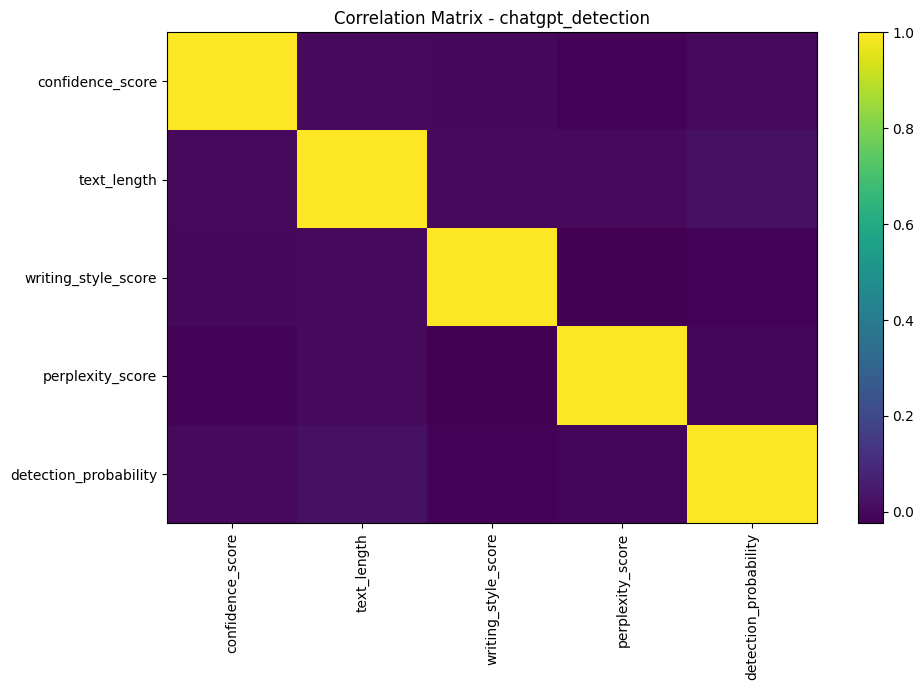

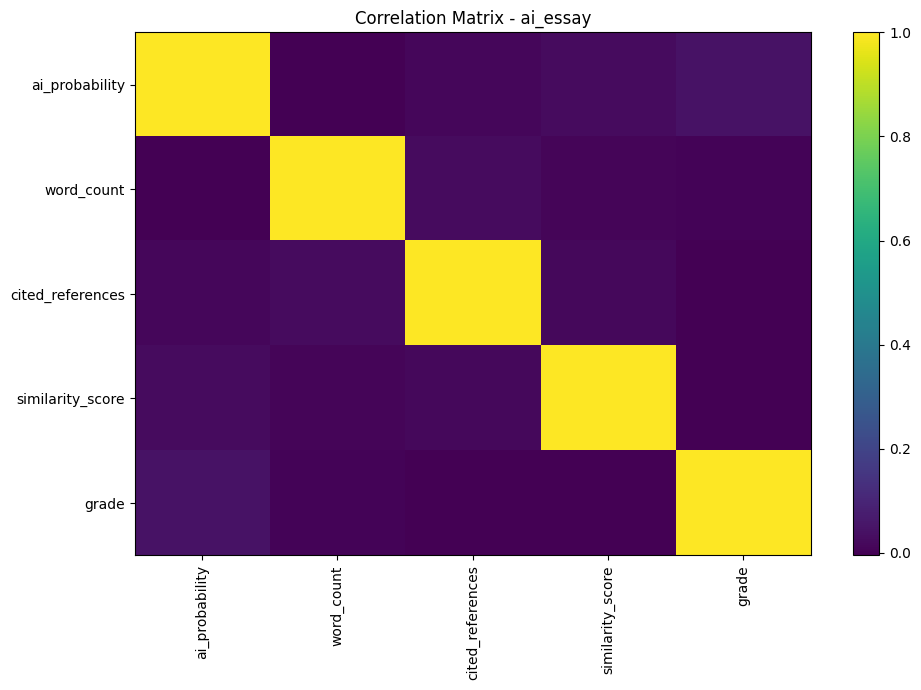

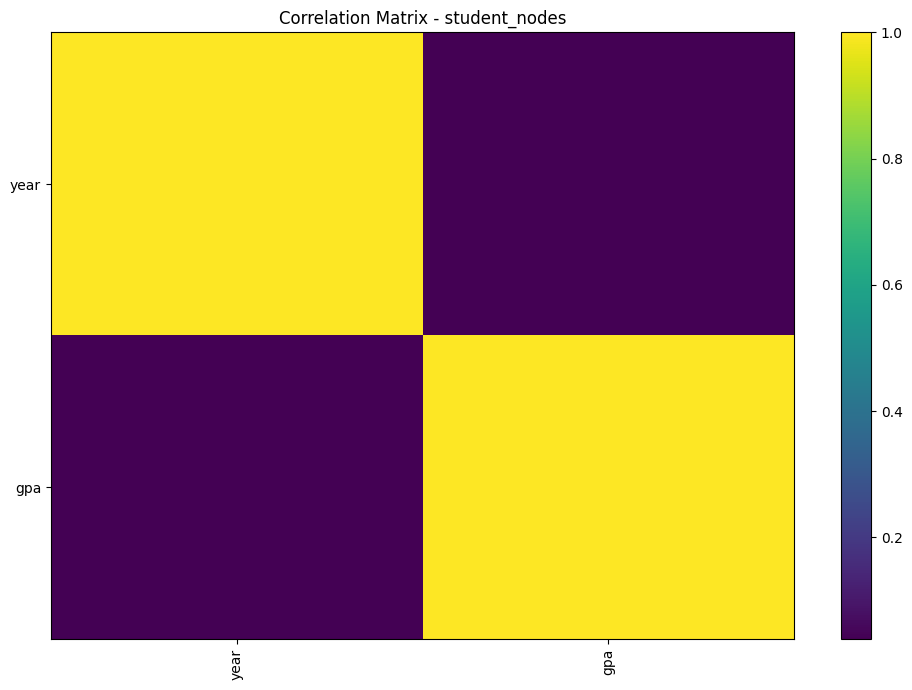

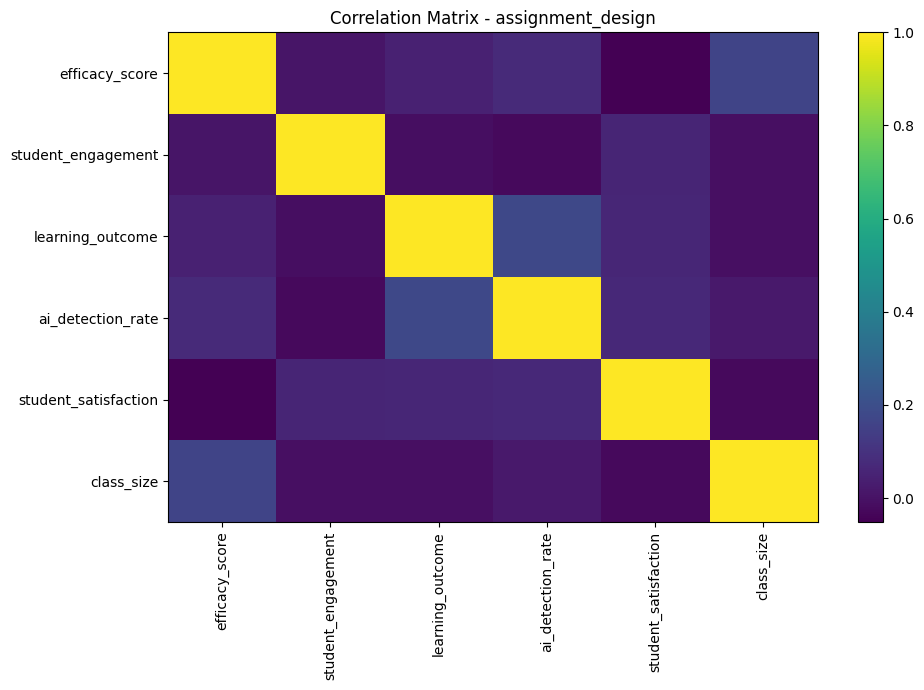

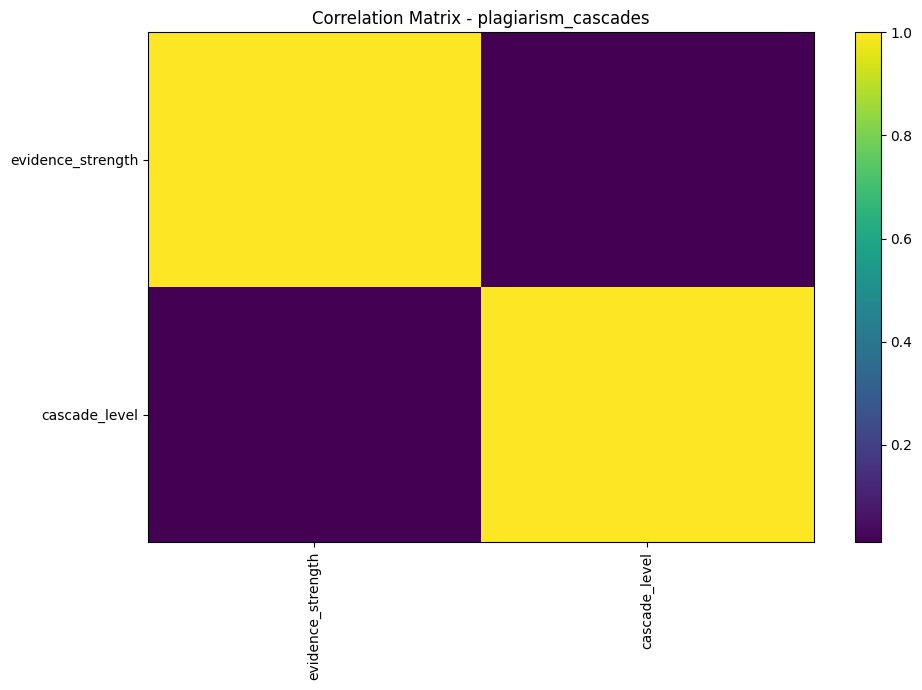

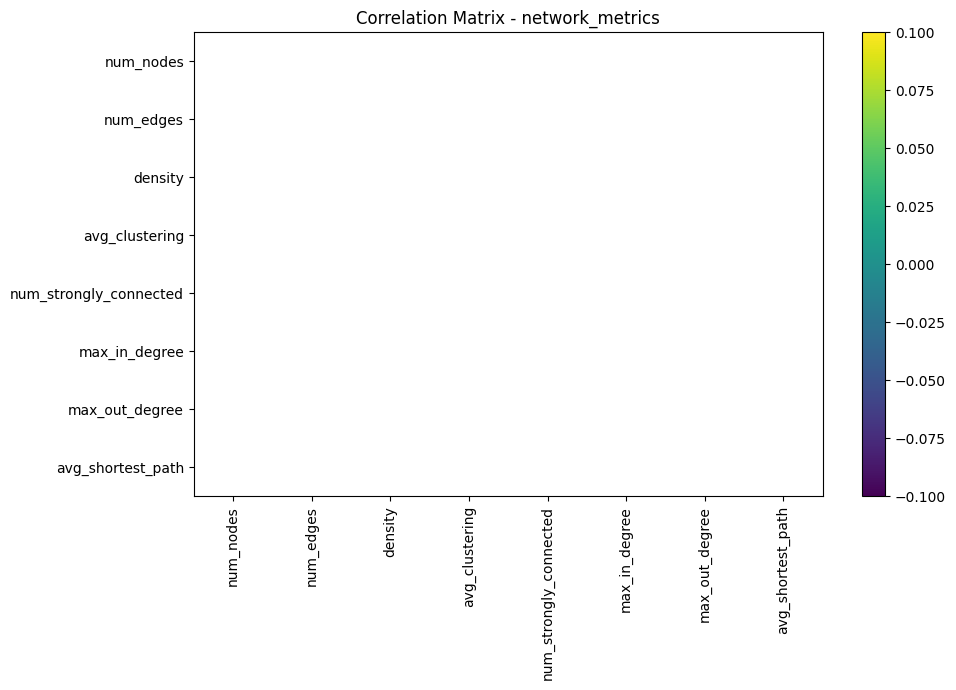

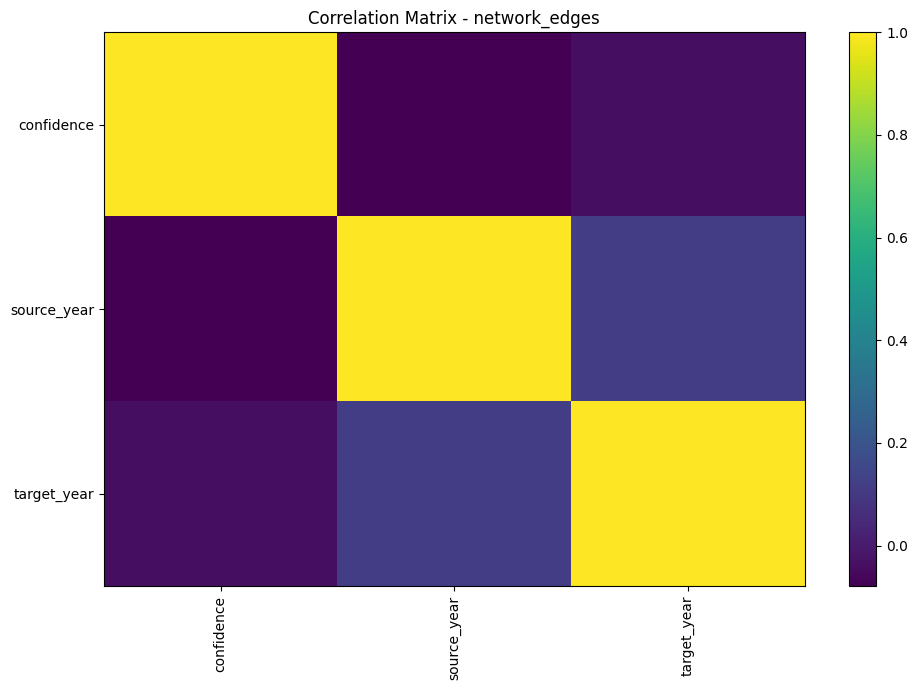

In [34]:
import matplotlib.pyplot as plt

for name, df in dfs.items():
    
    numeric_df = df.select_dtypes(
        include=np.number
    )
    
    if numeric_df.shape[1] >= 2:
        
        corr = numeric_df.corr()
        
        plt.figure(figsize=(10, 7))
        
        plt.imshow(
            corr,
            interpolation="nearest",
            aspect="auto"
        )
        
        plt.xticks(
            range(len(corr.columns)),
            corr.columns,
            rotation=90
        )
        
        plt.yticks(
            range(len(corr.columns)),
            corr.columns
        )
        
        plt.colorbar()
        plt.title(f"Correlation Matrix - {name}")
        plt.tight_layout()
        plt.show()

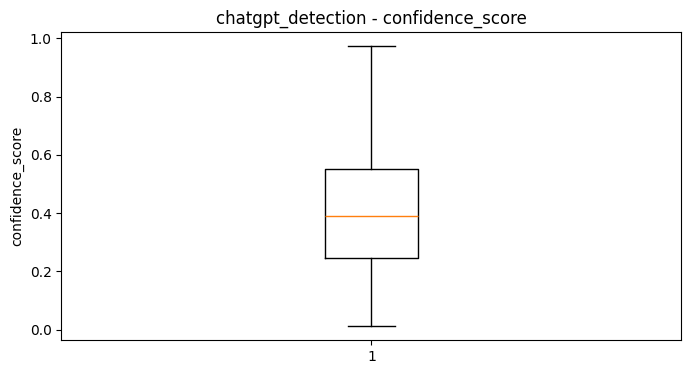

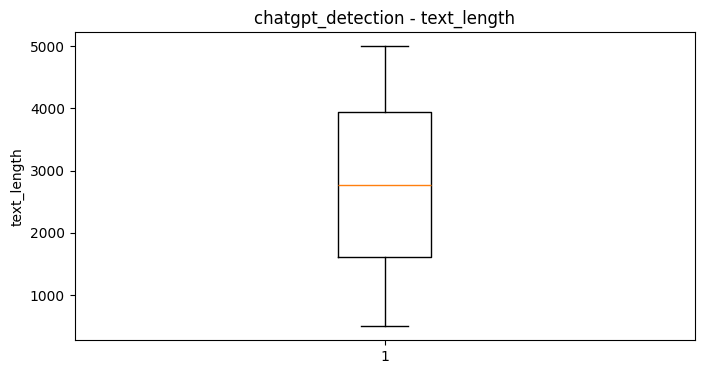

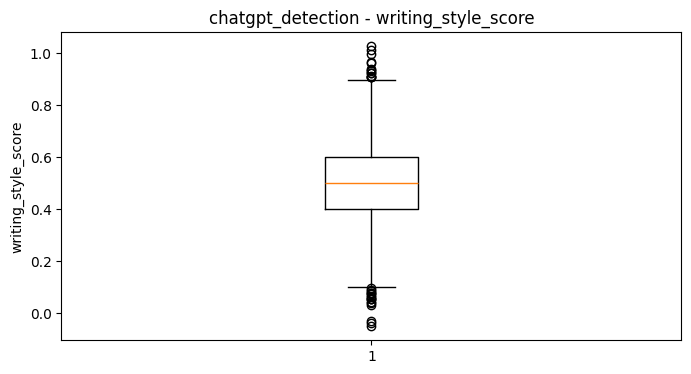

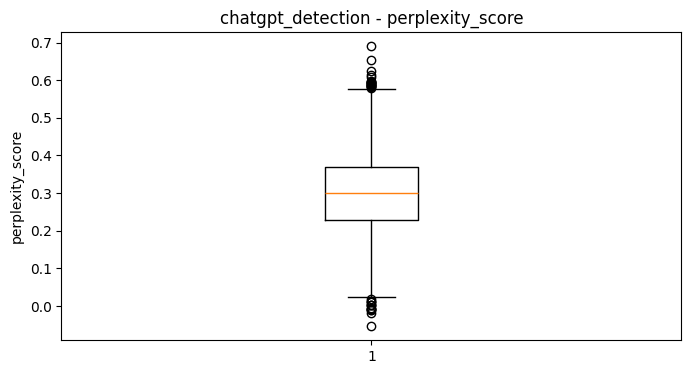

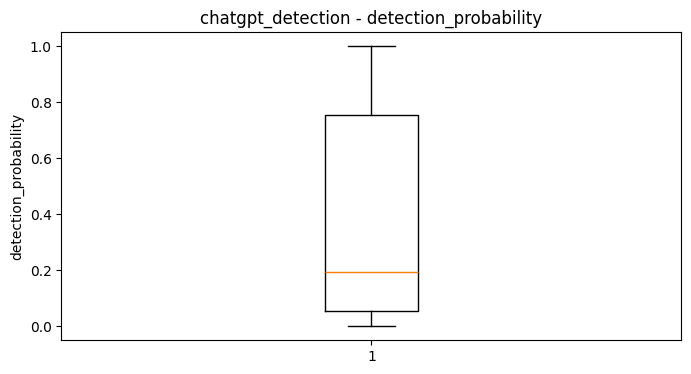

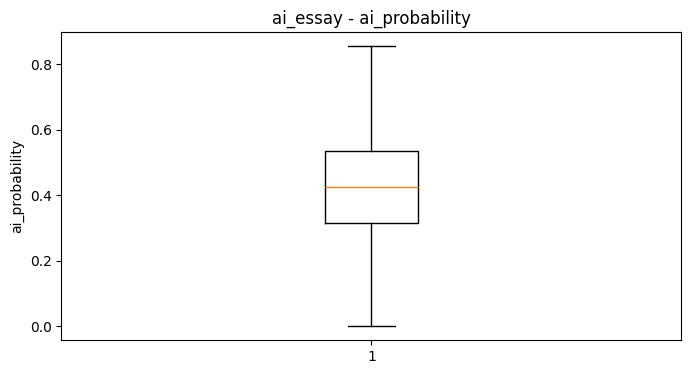

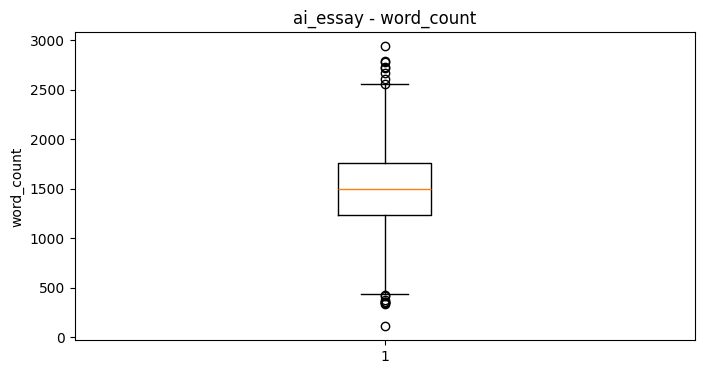

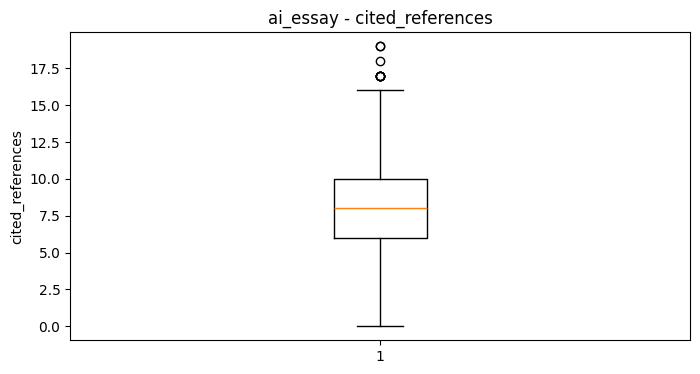

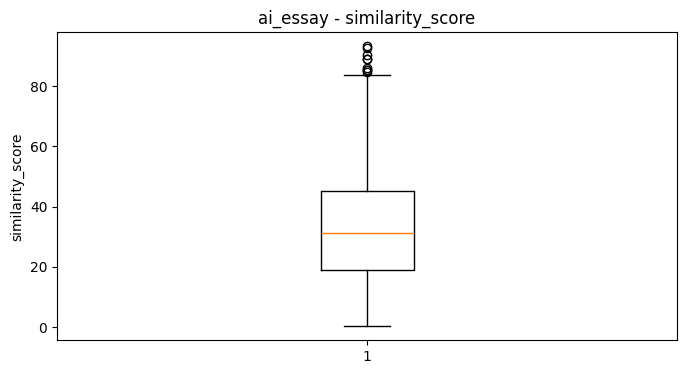

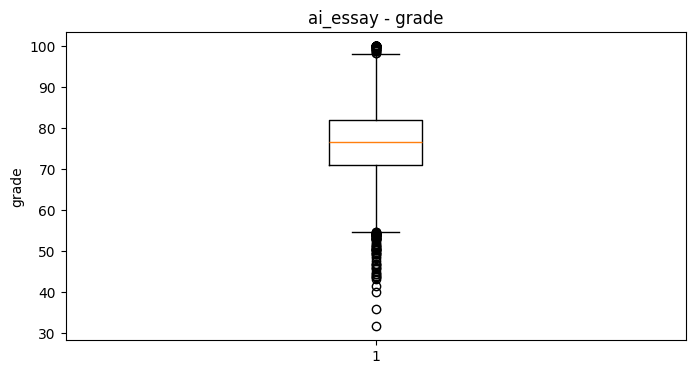

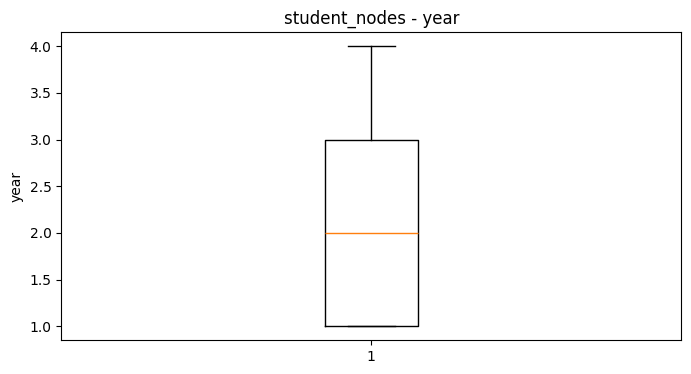

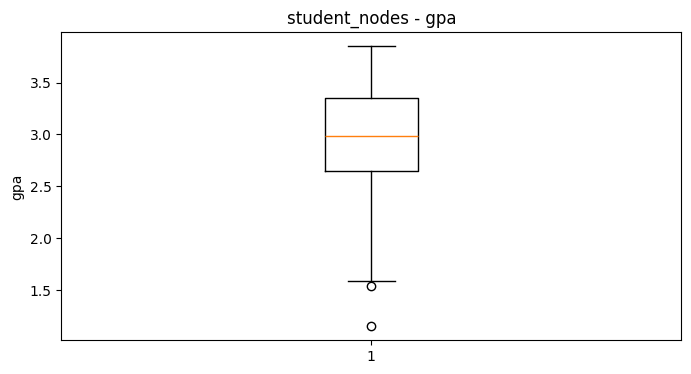

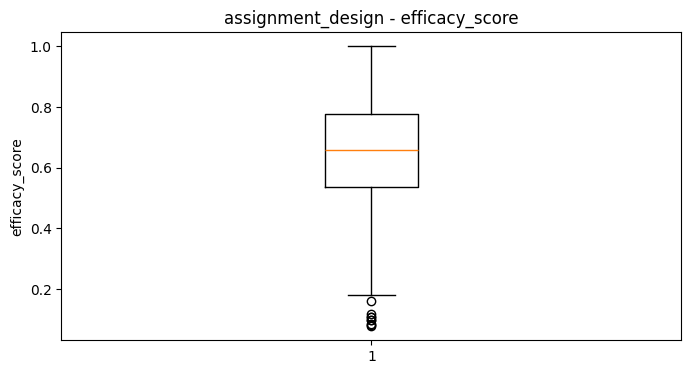

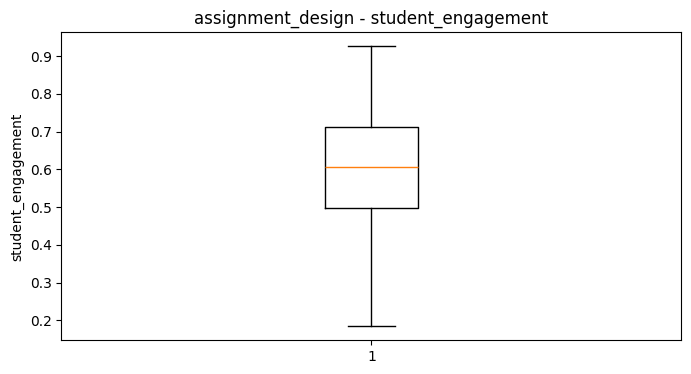

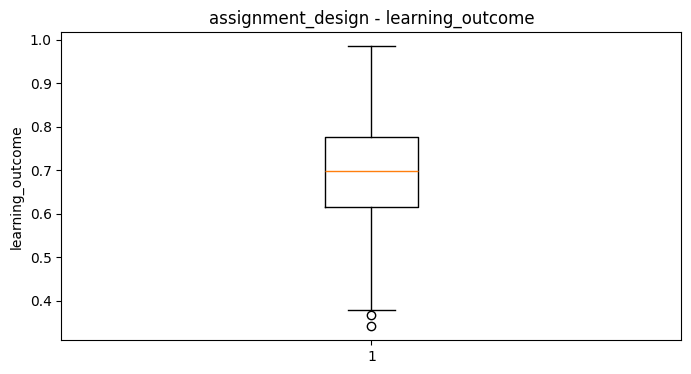

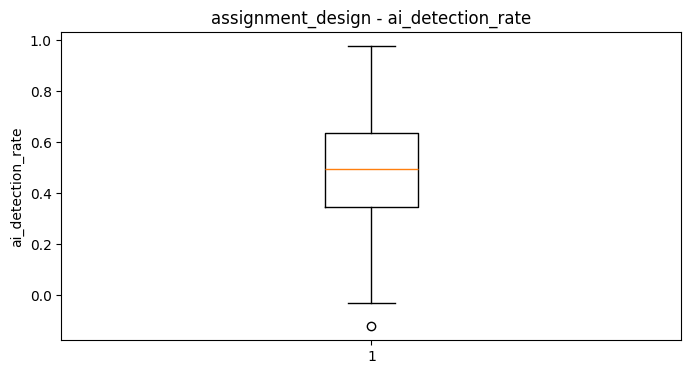

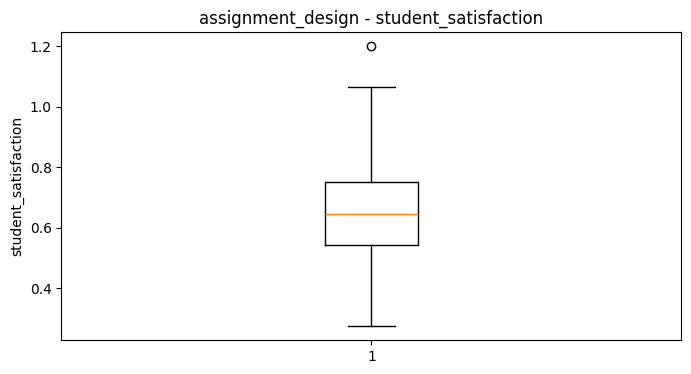

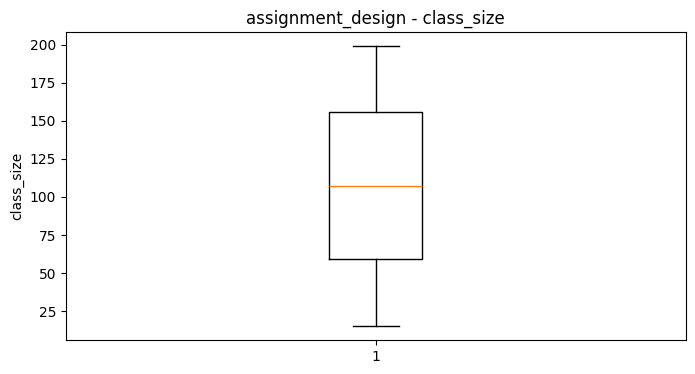

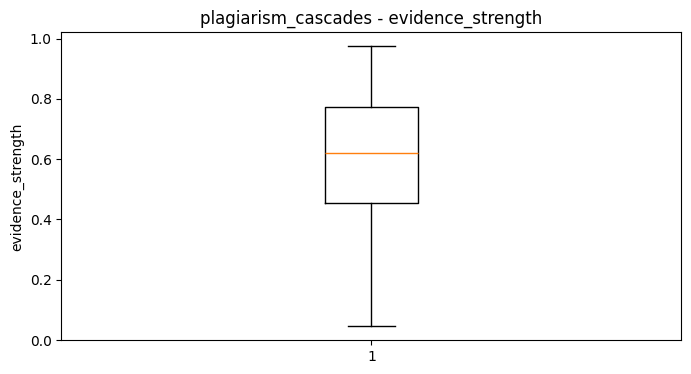

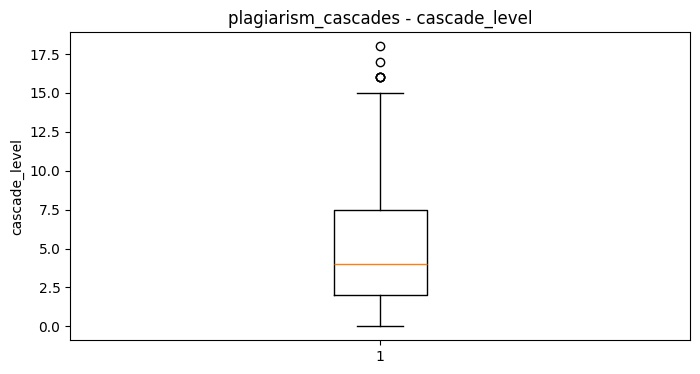

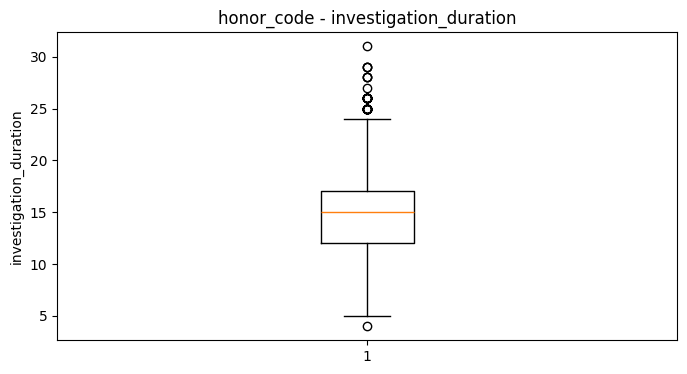

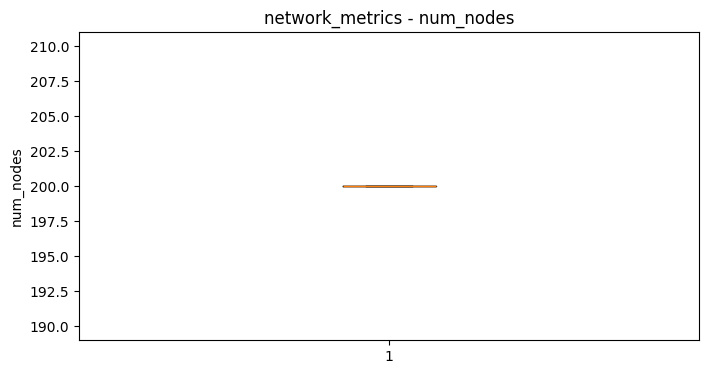

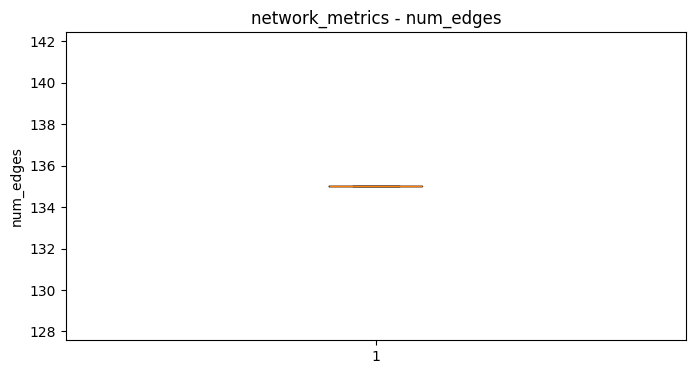

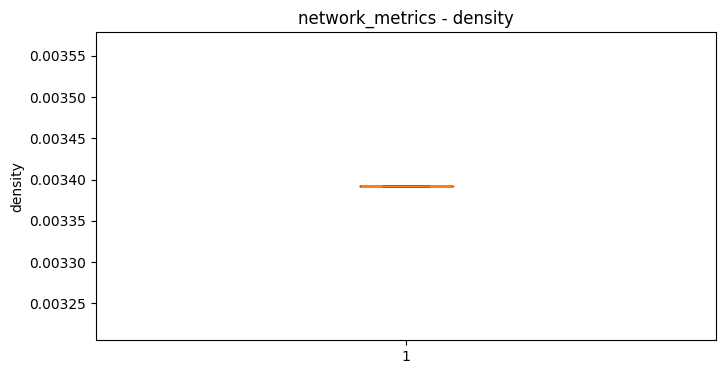

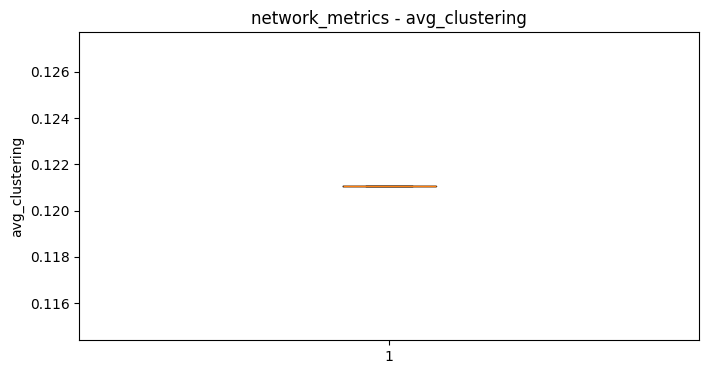

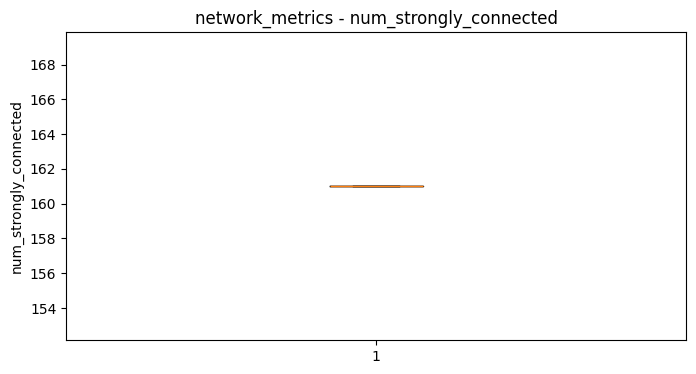

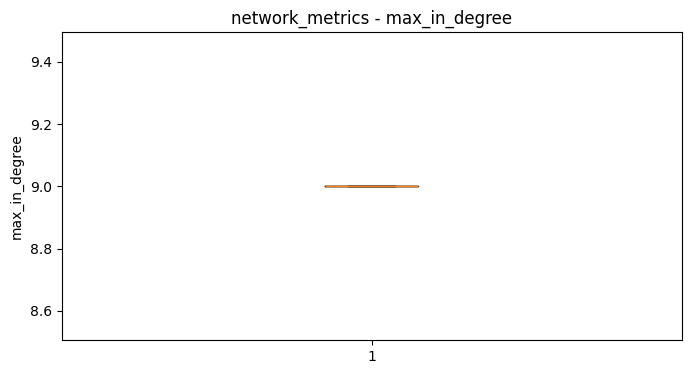

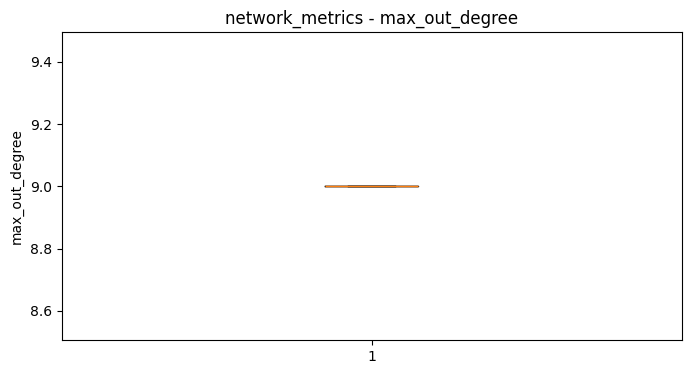

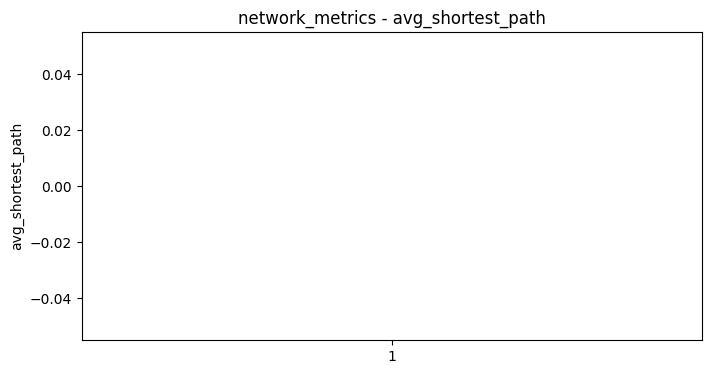

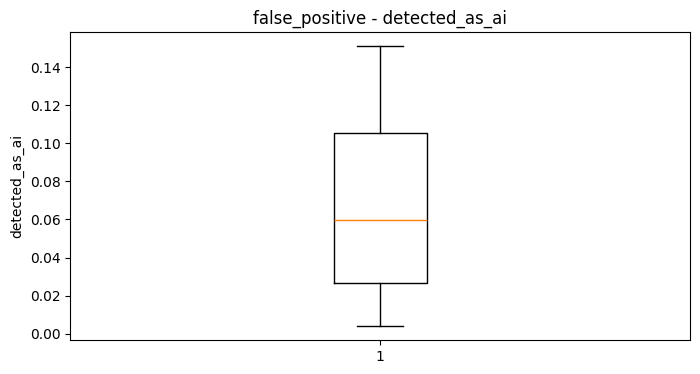

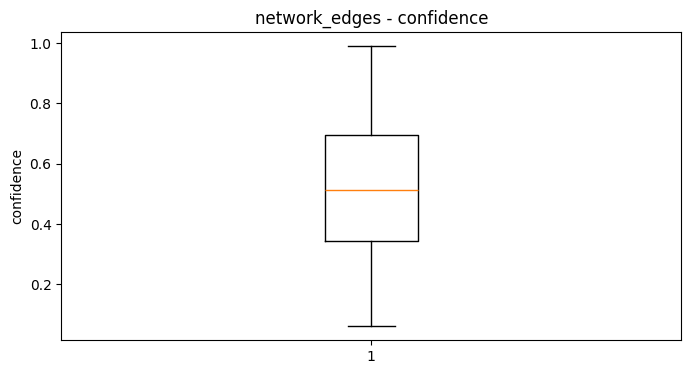

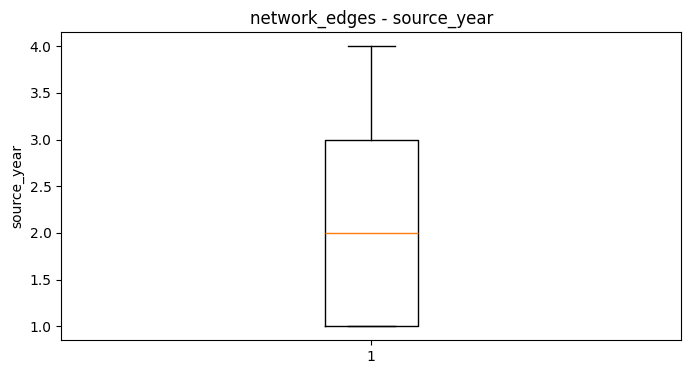

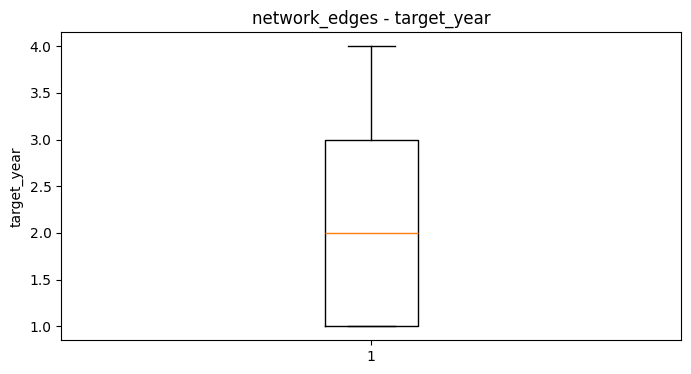

In [35]:
for name, df in dfs.items():
    
    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns
    
    for col in numeric_cols:
        
        plt.figure(figsize=(8, 4))
        
        plt.boxplot(
            df[col].dropna()
        )
        
        plt.title(
            f"{name} - {col}"
        )
        
        plt.ylabel(col)
        plt.show()

In [36]:
optimized_dfs = {}

for name, df in dfs.items():
    
    temp = df.copy()
    
    categorical_cols = temp.select_dtypes(
        include="object"
    ).columns
    
    for col in categorical_cols:
        temp[col] = temp[col].astype("category")
    
    optimized_dfs[name] = temp

In [37]:
for name, df in optimized_dfs.items():
    
    memory = df.memory_usage(
        deep=True
    ).sum() / (1024 ** 2)
    
    print(
        f"{name}: {memory:.2f} MB"
    )

chatgpt_detection: 0.62 MB
ai_essay: 0.63 MB
student_nodes: 0.02 MB
assignment_design: 0.01 MB
plagiarism_cascades: 0.07 MB
honor_code: 0.13 MB
network_metrics: 0.00 MB
false_positive: 0.00 MB
network_edges: 0.03 MB


In [38]:
for name, df in dfs.items():
    
    print("\n", name)
    
    for col in df.columns:
        
        if "date" in col.lower() or "time" in col.lower():
            print(
                "Possible date column:",
                col
            )


 chatgpt_detection

 ai_essay
Possible date column: submission_date

 student_nodes

 assignment_design

 plagiarism_cascades
Possible date column: accusation_date

 honor_code
Possible date column: date

 network_metrics

 false_positive

 network_edges
Possible date column: timestamp


In [39]:
for name, df in dfs.items():
    
    for col in df.columns:
        
        if "date" in col.lower():
            
            try:
                dfs[name][col] = pd.to_datetime(
                    dfs[name][col],
                    errors="coerce"
                )
                
                print(
                    f"{name} -> converted {col}"
                )
            
            except Exception as e:
                print(e)

ai_essay -> converted submission_date
plagiarism_cascades -> converted accusation_date
honor_code -> converted date


In [40]:
for name, df in dfs.items():
    
    date_cols = [
        col for col in df.columns
        if pd.api.types.is_datetime64_any_dtype(df[col])
    ]
    
    for col in date_cols:
        
        df[f"{col}_year"] = df[col].dt.year
        df[f"{col}_month"] = df[col].dt.month
        df[f"{col}_day"] = df[col].dt.day
        df[f"{col}_dayofweek"] = df[col].dt.dayofweek

In [41]:
for name, df in dfs.items():
    
    print("\n", name)
    
    for col in df.columns:
        
        if (
            "id" in col.lower()
            or "student" in col.lower()
            or "node" in col.lower()
        ):
            print(
                col,
                "->",
                df[col].nunique(),
                "unique values"
            )


 chatgpt_detection
submission_id -> 5000 unique values
confidence_score -> 5000 unique values

 ai_essay
submission_id -> 3000 unique values

 student_nodes
student_id -> 200 unique values

 assignment_design
student_engagement -> 240 unique values
student_satisfaction -> 240 unique values

 plagiarism_cascades
cascade_id -> 50 unique values
student_id -> 175 unique values
evidence_strength -> 439 unique values

 honor_code

 network_metrics
num_nodes -> 1 unique values

 false_positive

 network_edges
confidence -> 135 unique values


In [42]:
dataset_columns = {
    name: set(df.columns)
    for name, df in dfs.items()
}

for name1, cols1 in dataset_columns.items():
    
    for name2, cols2 in dataset_columns.items():
        
        if name1 < name2:
            
            common = cols1.intersection(cols2)
            
            if common:
                print(
                    f"{name1} <-> {name2}"
                )
                print(
                    "Common columns:",
                    list(common)
                )

chatgpt_detection <-> plagiarism_cascades
Common columns: ['subject']
chatgpt_detection <-> false_positive
Common columns: ['tool', 'detected_as_ai']
ai_essay <-> chatgpt_detection
Common columns: ['submission_id']
assignment_design <-> chatgpt_detection
Common columns: ['subject']
assignment_design <-> plagiarism_cascades
Common columns: ['subject']
plagiarism_cascades <-> student_nodes
Common columns: ['student_id']


In [43]:
for name, df in dfs.items():
    
    possible_keys = [
        col for col in df.columns
        if any(keyword in col.lower()
               for keyword in [
                   "student",
                   "student_id",
                   "node",
                   "id"
               ])
    ]
    
    print(
        f"{name}: {possible_keys}"
    )

chatgpt_detection: ['submission_id', 'confidence_score']
ai_essay: ['submission_id']
student_nodes: ['student_id']
assignment_design: ['student_engagement', 'student_satisfaction']
plagiarism_cascades: ['cascade_id', 'student_id', 'evidence_strength']
honor_code: []
network_metrics: ['num_nodes']
false_positive: []
network_edges: ['confidence']


## Feature engineering

LOADING DATASETS
chatgpt_detection         Rows =   5000 | Columns =   11
ai_essay                  Rows =   3000 | Columns =   10
student_nodes             Rows =    200 | Columns =    4
assignment_design         Rows =    240 | Columns =   10
plagiarism_cascades       Rows =    439 | Columns =    9
honor_code                Rows =   5095 | Columns =    7
network_metrics           Rows =      1 | Columns =    8
false_positive            Rows =      5 | Columns =    2
network_edges             Rows =    135 | Columns =    9


AVAILABLE COLUMNS

Dataset: chatgpt_detection
Columns:
   submission_id
   tool
   actual_type
   detected_as_ai
   confidence_score
   text_length
   subject
   grade_level
   writing_style_score
   perplexity_score
   detection_probability

Dataset: ai_essay
Columns:
   submission_id
   semester
   assignment_type
   is_ai_generated
   ai_probability
   word_count
   cited_references
   similarity_score
   submission_date
   grade

Dataset: student_nodes
Columns

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,84.8,84.75,84.8,84.77
1,Random Forest,84.5,84.41,84.5,84.43
2,Gradient Boosting,84.3,84.20,84.3,84.22
3,Naive Bayes,84.2,84.10,84.2,84.02
4,SVM,83.6,83.52,83.6,83.35
5,KNN,81.7,81.55,81.7,81.58
6,Decision Tree,76.1,76.25,76.1,76.16




BEST MODEL
Best Model: Logistic Regression
Accuracy: 84.8 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       False       0.87      0.88      0.88       620
        True       0.81      0.79      0.80       380

    accuracy                           0.85      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.85      0.85      0.85      1000



CONFUSION MATRIX


,False,True
False,548,72
True,80,300


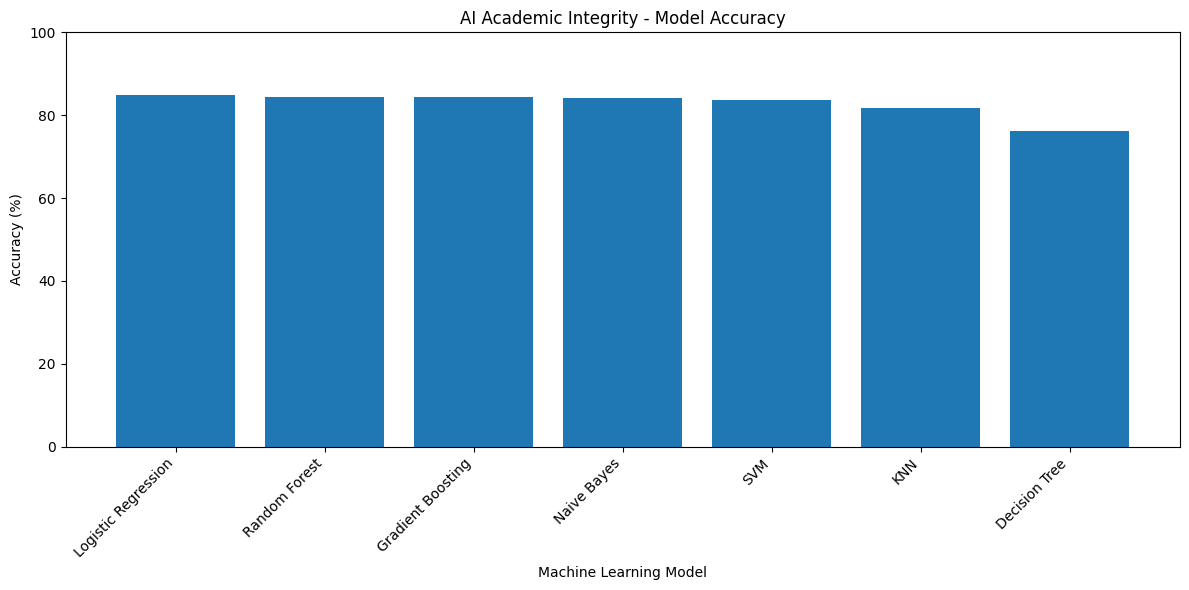



Results saved to:
/kaggle/working/model_accuracy_results.csv


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC




files = {
    "chatgpt_detection": "chatgpt_detection_results.csv",
    "ai_essay": "ai_essay_submissions.csv",
    "student_nodes": "student_nodes.csv",
    "assignment_design": "assignment_design_efficacy.csv",
    "plagiarism_cascades": "plagiarism_cascades.csv",
    "honor_code": "honor_code_violations.csv",
    "network_metrics": "network_metrics.csv",
    "false_positive": "false_positive_rates.csv",
    "network_edges": "cheating_network_edges.csv"
}

dfs = {}

print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

for name, filename in files.items():

    path = os.path.join(BASE_PATH, filename)

    if os.path.exists(path):

        df = pd.read_csv(path)

        dfs[name] = df

        print(
            f"{name:25} "
            f"Rows = {df.shape[0]:6} | "
            f"Columns = {df.shape[1]:4}"
        )

    else:
        print("FILE NOT FOUND:", path)


# ============================================================
# 4. DISPLAY ALL COLUMNS
# ============================================================

print("\n")
print("=" * 80)
print("AVAILABLE COLUMNS")
print("=" * 80)

for name, df in dfs.items():

    print("\nDataset:", name)
    print("Columns:")

    for col in df.columns:
        print("  ", col)


# ============================================================
# 5. SELECT DATASET FOR MACHINE LEARNING
# ============================================================

# We select ChatGPT detection dataset first because it is
# directly related to AI detection/classification.

if "chatgpt_detection" in dfs:

    df = dfs["chatgpt_detection"].copy()

else:

    # fallback
    first_dataset = list(dfs.keys())[0]
    df = dfs[first_dataset].copy()

    print(
        "\nUsing fallback dataset:",
        first_dataset
    )


print("\n")
print("=" * 80)
print("SELECTED DATASET")
print("=" * 80)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================================
# 6. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

print("\nCleaned columns:")
print(df.columns.tolist())


# ============================================================
# 7. REMOVE COMPLETELY EMPTY COLUMNS
# ============================================================

df = df.dropna(axis=1, how="all")


# ============================================================
# 8. REMOVE DUPLICATE ROWS
# ============================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nDuplicate rows removed:", before - after)


# ============================================================
# 9. FIND POSSIBLE TARGET COLUMNS
# ============================================================

target_keywords = [
    "target",
    "label",
    "class",
    "prediction",
    "predicted",
    "result",
    "detected",
    "ai_generated",
    "is_ai",
    "cheating",
    "violation",
    "flag"
]

possible_targets = []

for col in df.columns:

    col_lower = col.lower()

    for keyword in target_keywords:

        if keyword in col_lower:

            possible_targets.append(col)

            break


print("\n")
print("=" * 80)
print("POSSIBLE TARGET COLUMNS")
print("=" * 80)

print(possible_targets)


# ============================================================
# 10. SELECT TARGET COLUMN
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
#
# If you know the exact target column, put it here.
#
# Example:
#
# TARGET = "is_ai_generated"
#
# or
#
# TARGET = "prediction"
#
# ------------------------------------------------------------

TARGET = None


# Automatic target selection
if TARGET is None:

    if len(possible_targets) > 0:

        # Prefer columns that have relatively few classes
        candidates = []

        for col in possible_targets:

            unique_count = df[col].nunique()

            if 2 <= unique_count <= 20:

                candidates.append(
                    (col, unique_count)
                )

        if len(candidates) > 0:

            # Prefer smallest number of classes
            candidates.sort(
                key=lambda x: x[1]
            )

            TARGET = candidates[0][0]


# If no target automatically found
if TARGET is None:

    # Select last categorical column with
    # 2-20 unique values

    categorical_columns = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    candidates = []

    for col in categorical_columns:

        unique_count = df[col].nunique()

        if 2 <= unique_count <= 20:

            candidates.append(col)

    if len(candidates) > 0:

        TARGET = candidates[-1]


print("\n")
print("=" * 80)
print("SELECTED TARGET")
print("=" * 80)

print("TARGET =", TARGET)


# ============================================================
# 11. STOP IF TARGET WAS NOT FOUND
# ============================================================

if TARGET is None:

    raise ValueError(
        "Target column could not be detected. "
        "Print df.columns and manually set TARGET."
    )


# ============================================================
# 12. DISPLAY TARGET DISTRIBUTION
# ============================================================

print("\n")
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    df[TARGET]
    .value_counts(dropna=False)
)

print("\nTarget percentage:")

print(
    (
        df[TARGET]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


# ============================================================
# 13. REMOVE ROWS WITH MISSING TARGET
# ============================================================

df = df.dropna(
    subset=[TARGET]
).reset_index(drop=True)


# ============================================================
# 14. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=[TARGET]
)

y = df[TARGET]


print("\n")
print("=" * 80)
print("FEATURES AND TARGET")
print("=" * 80)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 15. REMOVE ID COLUMNS
# ============================================================

# IDs usually should not be used as ML features because they
# identify records rather than represent meaningful patterns.

id_columns = []

for col in X.columns:

    col_lower = col.lower()

    if (
        col_lower == "id"
        or col_lower.endswith("_id")
        or "student_id" in col_lower
        or "submission_id" in col_lower
        or "node_id" in col_lower
    ):

        id_columns.append(col)


print("\nID columns detected:")

print(id_columns)


if len(id_columns) > 0:

    X = X.drop(
        columns=id_columns
    )


# ============================================================
# 16. HANDLE DATETIME COLUMNS
# ============================================================

for col in X.columns:

    if (
        "date" in col.lower()
        or "time" in col.lower()
    ):

        try:

            converted = pd.to_datetime(
                X[col],
                errors="coerce"
            )

            # Create useful date features

            X[col + "_year"] = converted.dt.year
            X[col + "_month"] = converted.dt.month
            X[col + "_day"] = converted.dt.day
            X[col + "_dayofweek"] = converted.dt.dayofweek

            # Drop original date column

            X = X.drop(
                columns=[col]
            )

        except:

            pass


# ============================================================
# 17. HANDLE MISSING VALUES
# ============================================================

numeric_columns = X.select_dtypes(
    include=np.number
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns


# Numerical → median

for col in numeric_columns:

    X[col] = X[col].fillna(
        X[col].median()
    )


# Categorical → mode

for col in categorical_columns:

    mode_value = X[col].mode()

    if len(mode_value) > 0:

        X[col] = X[col].fillna(
            mode_value[0]
        )

    else:

        X[col] = X[col].fillna(
            "Unknown"
        )


# ============================================================
# 18. LABEL ENCODING
# ============================================================

print("\n")
print("=" * 80)
print("LABEL ENCODING")
print("=" * 80)

label_encoders = {}

# Encode target

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

print(
    "Target classes:"
)

for i, label in enumerate(
    target_encoder.classes_
):

    print(
        i,
        "=>",
        label
    )


# Encode categorical features

for col in X.select_dtypes(
    include=["object", "category", "bool"]
).columns:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = encoder

    print(
        f"{col} encoded"
    )


# ============================================================
# 19. CONVERT EVERYTHING TO NUMERIC
# ============================================================

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.fillna(0)


# ============================================================
# 20. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n")
print("=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

print(
    "Training features:",
    X_train.shape[1]
)

print(
    "Testing features:",
    X_test.shape[1]
)


# ============================================================
# 21. STANDARD SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# 22. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            kernel="rbf",
            random_state=42
        )
}


# ============================================================
# 23. TRAIN ALL MODELS
# ============================================================

results = []

predictions = {}

print("\n")
print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)

for name, model in models.items():

    print(
        f"\nTraining: {name}"
    )

    # Models such as Logistic Regression, KNN and SVM
    # benefit from scaled data.

    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )


    predictions[name] = y_pred


    # Metrics

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    results.append({

        "Model": name,

        "Accuracy (%)":
            round(accuracy * 100, 2),

        "Precision (%)":
            round(precision * 100, 2),

        "Recall (%)":
            round(recall * 100, 2),

        "F1 Score (%)":
            round(f1 * 100, 2)

    })


    print(
        f"Accuracy:  {accuracy * 100:.2f}%"
    )

    print(
        f"Precision: {precision * 100:.2f}%"
    )

    print(
        f"Recall:    {recall * 100:.2f}%"
    )

    print(
        f"F1 Score:  {f1 * 100:.2f}%"
    )


# ============================================================
# 24. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 80)
print("FINAL MODEL ACCURACY COMPARISON")
print("=" * 80)

display(
    results_df
)


# ============================================================
# 25. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy (%)"]


print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    "Best Model:",
    best_model_name
)

print(
    "Accuracy:",
    best_accuracy,
    "%"
)


# ============================================================
# 26. CLASSIFICATION REPORT FOR BEST MODEL
# ============================================================

best_prediction = predictions[
    best_model_name
]

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        best_prediction,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 27. CONFUSION MATRIX
# ============================================================

print("\n")
print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(
    y_test,
    best_prediction
)

cm_df = pd.DataFrame(
    cm,
    index=target_encoder.classes_,
    columns=target_encoder.classes_
)

display(cm_df)


# ============================================================
# 28. FEATURE IMPORTANCE
# ============================================================

if best_model_name in [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
]:

    best_model = models[
        best_model_name
    ]

    importance_df = pd.DataFrame({

        "Feature":
            X.columns,

        "Importance":
            best_model.feature_importances_

    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n")
    print("=" * 80)
    print("FEATURE IMPORTANCE")
    print("=" * 80)

    display(
        importance_df.head(20)
    )


# ============================================================
# 29. ACCURACY BAR CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "AI Academic Integrity - Model Accuracy"
)

plt.ylim(
    0,
    100
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "/kaggle/working/model_accuracy_results.csv",
    index=False
)

print("\n")
print(
    "Results saved to:"
)

print(
    "/kaggle/working/model_accuracy_results.csv"
)

## Thank you..pls upvote!!!!!!!!!!
